In [1]:
import pickle
import os
import pandas as pd
import networkx as nx
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as scp
from scipy.stats import ranksums
import gzip

In [3]:
hippiedata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/hippie/"
genelistdata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/genelist/"
hisigdata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/genelist/hisig/"
UCSCtoilpath="/home/ajayasha/scratch/Arvind_umd/UCSC-TOIL/"
ECMprojpath="/home/ajayasha/scratch/Arvind_umd/ECM_proj/"
RCDprojpath="/home/ajayasha/scratch/Arvind_umd/RCD/"
GDCPANCANpath="/home/ajayasha/scratch/Arvind_umd/GDC-PANCAN/"
#os.system("mkdir -p "+congenelistdata2)
ecmcm_module="/home/ajayasha/scratch/Arvind_umd/ECM_proj/ecmcmmodule/"
ecmcm_module2="/home/ajayasha/scratch/Arvind_umd/ecmcmmodule/for_r/"
#os.system("mkdir -p "+ecmcm_module)
#os.system("mkdir -p "+ecmcm_module2)
#os.system("mkdir -p "+hisigdata)

In [3]:
##load hcmod
with open(hippiedata+'hcmod.pkl', 'rb') as f:
    hc_supmod=pickle.load(f)
##load contextmod
#with open('context_ecmcmmod_lc.pkl', 'rb') as f:
#    context_ecmcm_mods=pickle.load(f)
#with open('context_ecmcmmod_dist.pkl', 'rb') as f:
#    context_ecmcm_mods_dist=pickle.load(f)
##load gcorrval
#with open('95gcorrval.pkl', 'rb') as f:
#    gcorrval=pickle.load(f)

In [4]:
tcganatgtex=pd.read_csv(ECMprojpath+"tcganatgtex.txt",sep="\t",index_col=0)
tcganatgtex.dropna(how='all',subset=["NAT","GTEX"],inplace=True)
tcganatgtex

,Cancer,NAT,GTEX
TARGET-ALL1,Acute Lymphoblastic Leukemia_White blood cell_...,NaN,Whole Blood_Blood_Normal Tissue
TARGET-ALL2,Acute Lymphoblastic Leukemia_White blood cell_...,NaN,Whole Blood_Blood_Normal Tissue
TARGET-ALL3,Acute Lymphoblastic Leukemia_White blood cell_...,NaN,Whole Blood_Blood_Normal Tissue
TARGET-AML1,Acute Myeloid Leukemia_White blood cell_Primar...,NaN,Whole Blood_Blood_Normal Tissue
TCGA-LAML,Acute Myeloid Leukemia_White blood cell_Primar...,NaN,Whole Blood_Blood_Normal Tissue
TARGET-AML2,Acute Myeloid Leukemia_White blood cell_Recurr...,NaN,Whole Blood_Blood_Normal Tissue
TARGET-AML3,"Acute Myeloid Leukemia, Induction Failure Subp...",NaN,Whole Blood_Blood_Normal Tissue
TARGET-AML4,"Acute Myeloid Leukemia, Induction Failure Subp...",NaN,Whole Blood_Blood_Normal Tissue
TCGA-ACC,Adrenocortical Cancer_Adrenal gland_Primary Tumor,NaN,Adrenal Gland_Adrenal Gland_Normal Tissue
TCGA-BLCA,Bladder Urothelial Carcinoma_Bladder_Primary T...,Bladder Urothelial Carcinoma_Bladder_Solid Tis...,NaN


In [5]:
all_hgnc=pd.read_csv(genelistdata+"all_hgnc_biomart.txt",sep='\t',index_col=8, dtype={'NCBI gene ID': str})
ens2entrez=all_hgnc['NCBI gene ID'].to_dict()
all_hgnc[['Approved symbol','NCBI gene ID']]
symtoncbidict=dict(zip(all_hgnc['Approved symbol'].values.tolist(),all_hgnc['NCBI gene ID'].values.tolist()))
mat=pd.read_csv(genelistdata+"matrisome_hs_masterlist.tsv",sep="\t",index_col=5)
ecmcatdict=mat['Category'].astype(str).to_dict()
ecmgenes=pd.read_csv(genelistdata+"matrisome_wids_sortu.txt",sep="\t",index_col=6)
ecmdictpre=ecmgenes['HGNC ID'].astype(str).to_dict()
ecmcatdict={str(int(k)): v for k,v in ecmcatdict.items() if k == k}
ecmcatdict
ecmdictpre={k: v.split(':')[1] for k,v in ecmdictpre.items() if k == k}
ecmdictpre
tocheck=[]
ecmenscat={}
for ecm in ecmdictpre:
    if ecmdictpre[ecm] not in ecmcatdict:
        tocheck.append(ecm)
    else:
        ecmenscat[ecm]=ecmcatdict[ecmdictpre[ecm]]
ecmgenes.loc[tocheck]
ecmenscat['ENSG00000105509']='ECM Regulators'
ecmenscat['ENSG00000170961']='ECM Regulators'
ecmenscat['ENSG00000103044']='ECM Regulators'
tocheck.remove('ENSG00000105509')
tocheck.remove('ENSG00000170961')
tocheck.remove('ENSG00000103044')
for ecm in tocheck:
    ecmenscat[ecm]="n/a"
cmgenes=pd.read_csv(genelistdata+"crm_wids_sortu.txt",sep="\t",index_col=6)
cmdict=cmgenes['NCBI gene ID'].astype(str).to_dict()
ecmdict=ecmgenes['NCBI gene ID'].astype(str).to_dict()
ecmdict={k: v for k,v in ecmdict.items() if k == k}
cmdict={k: v for k,v in cmdict.items() if k == k}
allgenes=list(set(list(ecmdict.keys())+list(cmdict.keys())))
allgenes = [e for e in allgenes if e not in ('ENSG00000287080', 'ENSG00000286522')]
cmgenesl=[cmdict[e] for e in cmdict.keys() if e not in ('ENSG00000287080', 'ENSG00000286522')]
ecmgenesl=[ecmdict[e] for e in ecmdict.keys() if e not in ('ENSG00000287080', 'ENSG00000286522')]
coreecmgenesl=[ecmdict[e] for e in ecmenscat.keys() if ecmenscat[e] in ('ECM Glycoproteins','Collagens','Proteoglycans')]

In [6]:
entoens=dict(zip(all_hgnc['NCBI gene ID'].values.tolist(),all_hgnc.index.tolist()))
entodsym=dict(zip(all_hgnc[all_hgnc['NCBI gene ID'].notnull()]['NCBI gene ID'].values.tolist(),all_hgnc[all_hgnc['NCBI gene ID'].notnull()]['Approved symbol'].values.tolist()))

In [7]:
def flattenmed(xss):
    return list(set([x for xs in xss for x in xs]))
def flatten(xss):
    return list(set([x for xs in xss for x in xs]))

In [8]:
medgenesl=[]
for med in list(set(pd.DataFrame(hc_supmod)[0].apply(flatten).sum())):
    if med in entoens and (med not in coreecmgenesl and med not in cmgenesl):
        medgenesl.append(entoens[med])
allmod_ecmgenesl=[]
for ecm in list(set(pd.DataFrame(hc_supmod)[1].apply(list).sum())):
    if ecm in entoens:
        allmod_ecmgenesl.append(entoens[ecm])
allmod_cmgenesl=[]
for cm in list(set(pd.DataFrame(hc_supmod)[2].apply(list).sum())):
    if cm in entoens:
        allmod_cmgenesl.append(entoens[cm])

In [9]:
tcganatgtex_dict=tcganatgtex.to_dict()
combgenexfiles={}
for ctype in tcganatgtex_dict:
    for proj in tcganatgtex_dict[ctype]:
        if proj not in combgenexfiles:
            combgenexfiles[proj]=[]
        try:
            for file in tcganatgtex_dict[ctype][proj].split(","):
                combgenexfiles[proj].append(file)
        except:
            pass
combgenexfiles

{'TARGET-ALL1': ['Acute Lymphoblastic Leukemia_White blood cell_Primary Blood Derived Cancer - Bone Marrow',
  'Whole Blood_Blood_Normal Tissue'],
 'TARGET-ALL2': ['Acute Lymphoblastic Leukemia_White blood cell_Primary Blood Derived Cancer - Peripheral Blood',
  'Whole Blood_Blood_Normal Tissue'],
 'TARGET-ALL3': ['Acute Lymphoblastic Leukemia_White blood cell_Recurrent Blood Derived Cancer - Bone Marrow',
  'Whole Blood_Blood_Normal Tissue'],
 'TARGET-AML1': ['Acute Myeloid Leukemia_White blood cell_Primary Blood Derived Cancer - Bone Marrow',
  'Whole Blood_Blood_Normal Tissue'],
 'TCGA-LAML': ['Acute Myeloid Leukemia_White blood cell_Primary Blood Derived Cancer - Peripheral Blood',
  'Whole Blood_Blood_Normal Tissue'],
 'TARGET-AML2': ['Acute Myeloid Leukemia_White blood cell_Recurrent Blood Derived Cancer - Bone Marrow',
  'Whole Blood_Blood_Normal Tissue'],
 'TARGET-AML3': ['Acute Myeloid Leukemia',
  ' Induction Failure Subproject_White blood cell_Post treatment Blood Cancer - B

In [10]:
inv_combgenex={}
for ct in combgenexfiles:
    for file in combgenexfiles[ct]:
        inv_combgenex[file]=ct
sthued={}
for ct in inv_combgenex:
    if "_Primary Tumor" in ct:
        sthued[ct]="PT"
    elif "_Solid Tissue Normal" in ct:
        sthued[ct]="NAT"
    elif "_Metastatic" in ct:
        sthued[ct]="MT"
    elif "_Recurrent" in ct:
        sthued[ct]="RT"
    else:
        sthued[ct]="GTEX"

In [11]:
cat_sample=pd.read_csv(UCSCtoilpath+"TcgaTargetGTEX_phenotype.txt.gz", sep="\t",index_col=0,encoding="unicode_escape")

60498
60498
58581
60498


<AxesSubplot:>

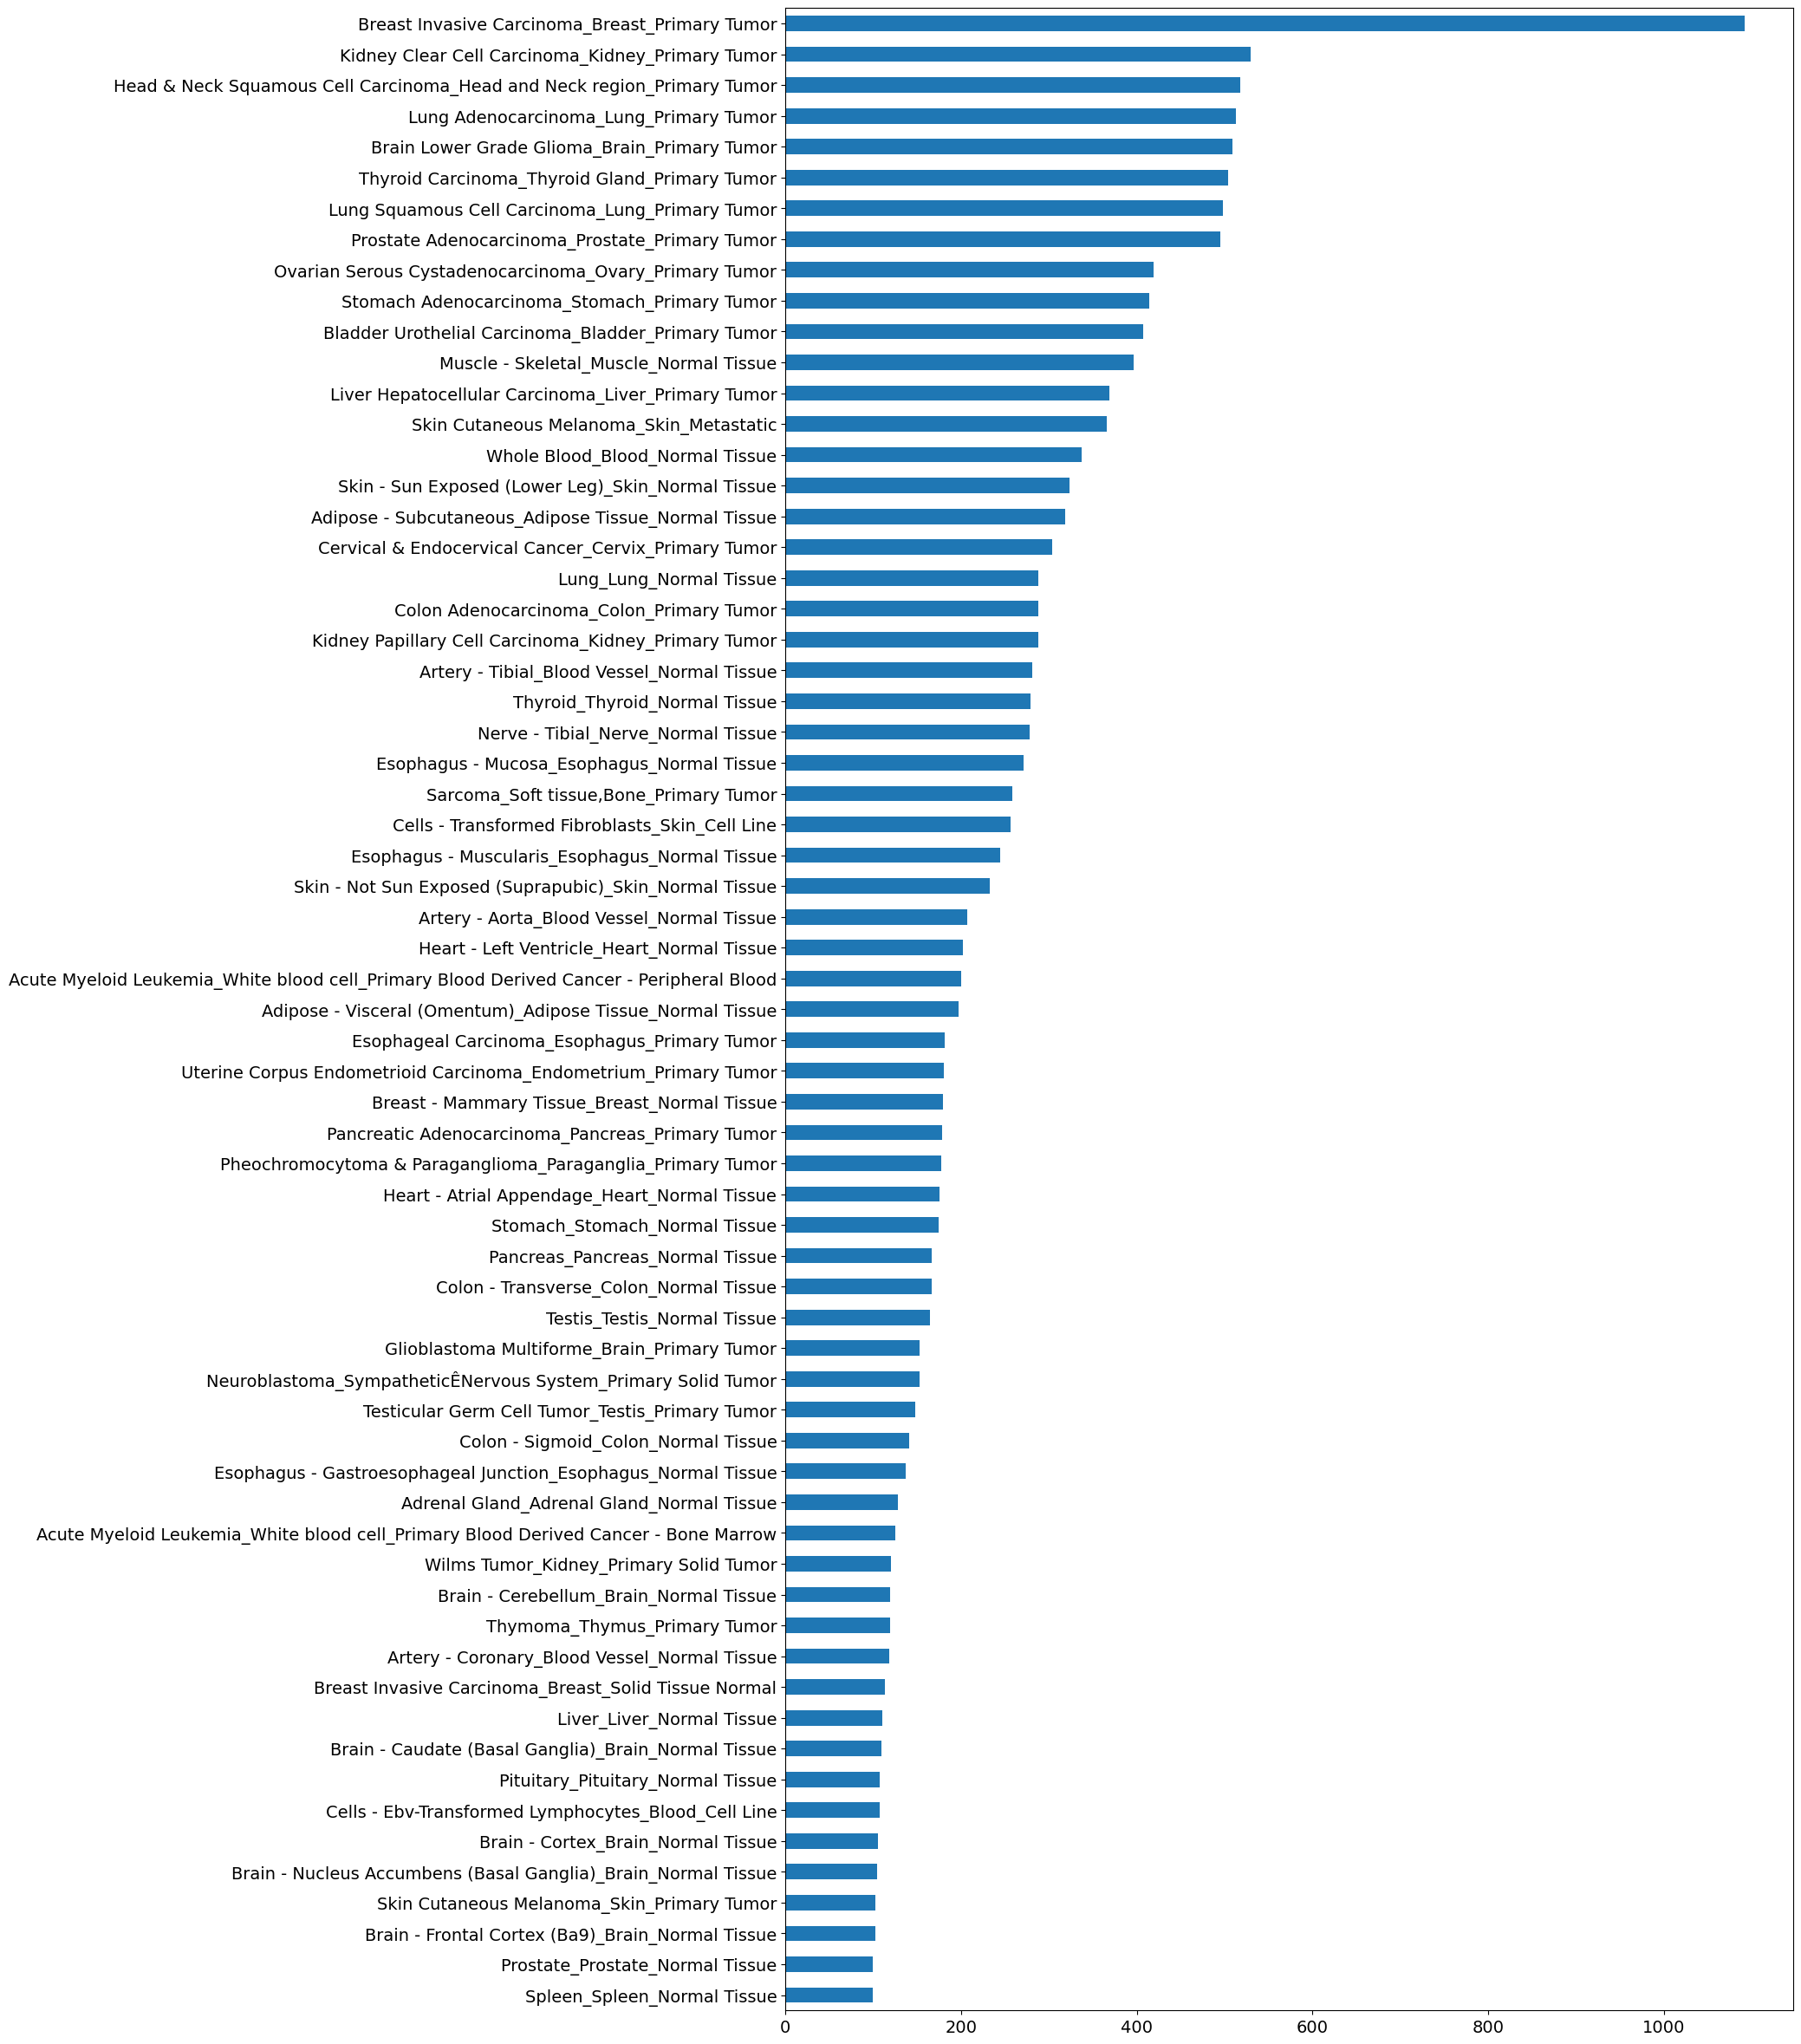

In [12]:
cat_sample=pd.read_csv(UCSCtoilpath+"TcgaTargetGTEX_phenotype.txt.gz", sep="\t",index_col=0,encoding="unicode_escape")
cat_sample.dropna(inplace=True,how='all')
cat_sdict=dict(cat_sample['primary disease or tissue']+"_"+cat_sample['_primary_site']+"_"+cat_sample['_sample_type'])
tcgagenemap=pd.read_csv(UCSCtoilpath+"probeMap%2Fgencode.v23.annotation.gene.probemap",sep="\t",index_col=0)
enslist=tcgagenemap.index.to_series().apply(lambda x: x.split('.')[0]).values.tolist()
print(len(enslist))#ensids
print(len(list(set(enslist))))#unique ensids
tcgaensdict=dict(zip(enslist,tcgagenemap['gene'].values.tolist()))
print(len(tcgagenemap['gene'].unique().tolist()))
print(len(tcgagenemap['gene']))
can_dict={}
can_dict_counts={}
for s in cat_sdict:
    if cat_sdict[s] not in can_dict.keys():
        can_dict[cat_sdict[s]]=[]
        can_dict[cat_sdict[s]].append(s)
    else:
        can_dict[cat_sdict[s]].append(s)
for c in can_dict:
    can_dict_counts[c]=len(can_dict[c])
candf=pd.Series(can_dict_counts)
candf.sort_values(inplace=True)
plt.rcParams['figure.figsize'] = [15, 30]
matrixlist=list(candf.loc[candf>=10].index)
candf.loc[candf>=100].plot(kind='barh',fontsize=14)

In [13]:
revcan_dict={}
for c in can_dict:
    revcan_dict[c]=[s.replace("-",".") for s in can_dict[c]]
revcan_dict

{'Uveal Melanoma_Eye_Primary Tumor': ['TCGA.V4.A9EE.01',
  'TCGA.VD.AA8N.01',
  'TCGA.V4.A9EI.01',
  'TCGA.VD.AA8O.01',
  'TCGA.WC.A888.01',
  'TCGA.WC.A881.01',
  'TCGA.WC.A88A.01',
  'TCGA.YZ.A980.01',
  'TCGA.V4.A9EO.01',
  'TCGA.WC.A87U.01',
  'TCGA.VD.A8KD.01',
  'TCGA.VD.AA8Q.01',
  'TCGA.VD.A8KH.01',
  'TCGA.V4.A9F8.01',
  'TCGA.VD.A8KF.01',
  'TCGA.VD.A8KI.01',
  'TCGA.V4.A9EA.01',
  'TCGA.VD.A8KM.01',
  'TCGA.V4.A9EQ.01',
  'TCGA.VD.AA8M.01',
  'TCGA.WC.A87T.01',
  'TCGA.WC.A880.01',
  'TCGA.V4.A9EL.01',
  'TCGA.WC.A885.01',
  'TCGA.WC.AA9E.01',
  'TCGA.V4.A9F0.01',
  'TCGA.WC.A87Y.01',
  'TCGA.V4.A9ET.01',
  'TCGA.V3.A9ZX.01',
  'TCGA.V4.A9EF.01',
  'TCGA.V3.A9ZY.01',
  'TCGA.VD.A8KK.01',
  'TCGA.V4.A9EH.01',
  'TCGA.V4.A9EM.01',
  'TCGA.VD.A8KJ.01',
  'TCGA.VD.A8KO.01',
  'TCGA.V4.A9E9.01',
  'TCGA.V4.A9E8.01',
  'TCGA.V4.A9ED.01',
  'TCGA.V4.A9F4.01',
  'TCGA.VD.AA8S.01',
  'TCGA.VD.A8K7.01',
  'TCGA.V4.A9EJ.01',
  'TCGA.VD.A8KA.01',
  'TCGA.V4.A9F5.01',
  'TCGA.V4.A9EU.01'

In [14]:
invsth={}
for ct in sthued:
    if sthued[ct] not in invsth:
        invsth[sthued[ct]]=[ct]
    else:
        invsth[sthued[ct]].append(ct)

In [15]:
invrevcan_dict={}
for c in revcan_dict:
    for st in revcan_dict[c]:
        invrevcan_dict[st]=c

In [16]:
invcombgenex={}
for proj in combgenexfiles:
    for ct in combgenexfiles[proj]:
        invcombgenex[ct]=proj

In [17]:
allECMfiles=[]
for file in os.listdir(ECMprojpath+"ssgsea/residuals_deconv/"):
    if file.endswith("_supmod_ecm.tsv"):
        test=pd.read_csv(ECMprojpath+"ssgsea/residuals_deconv/"+file,sep="\t",index_col=0)
        test.columns=test.columns.str.split().str[0]
        if not test.empty:
            allECMfiles.append(test.copy())
allCMfiles=[]
for file in os.listdir(ECMprojpath+"ssgsea/residuals_deconv/"):
    if file.endswith("_supmod_cm.tsv"):
        test=pd.read_csv(ECMprojpath+"ssgsea/residuals_deconv/"+file,sep="\t",index_col=0)
        test.columns=test.columns.str.split().str[0]
        if not test.empty:
            allCMfiles.append(test.copy())
allmedfiles=[]
for file in os.listdir(ECMprojpath+"ssgsea/residuals_deconv/"):
    if file.endswith("_supmod_med.tsv"):
        test=pd.read_csv(ECMprojpath+"ssgsea/residuals_deconv/"+file,sep="\t",index_col=0)
        test.columns=test.columns.str.split().str[0]
        if not test.empty:
            allmedfiles.append(test.copy())

In [18]:
transformedscores_1ecm=pd.concat(allECMfiles,axis=0)
transformedscores_1cm=pd.concat(allCMfiles,axis=0)
transformedscores_1med=pd.concat(allmedfiles,axis=0)
transformedscores_1cm.head()

,module_0,module_1,module_2,module_3,module_4,module_5,module_6,module_7,module_8,module_9,...,module_126,module_127,module_128,module_129,module_130,module_131,module_132,module_133,module_134,module_135
GTEX.VJYA.0005.SM.3P5ZD,-218.935768,-336.289914,-334.558355,-150.582638,-113.299749,-257.504035,-187.260055,336.771780,66.037823,336.376463,...,-267.570129,-306.305230,-370.652874,-312.481252,-93.991365,-369.003861,10.099645,-125.475918,-578.633198,245.242770
GTEX.POMQ.0006.SM.5SI7D,68.619847,-165.837994,12.693473,13.667375,-104.025747,24.538728,-20.850381,106.314549,18.977379,101.044093,...,-60.918128,-76.387145,212.086739,-74.614228,356.944744,-20.848502,319.330041,89.476306,-114.796256,-282.606501
GTEX.1399Q.0005.SM.5NQAG,479.274365,538.838562,379.496087,270.329496,582.183025,427.601181,419.939051,513.744971,388.567638,680.257916,...,779.721727,437.051700,355.969297,145.275491,616.949872,338.431024,620.072665,139.064731,335.882429,1099.485583
GTEX.ZPIC.0005.SM.4WWEB,-176.484448,59.647530,-191.752309,3.150218,-216.932925,-195.538106,-146.199598,192.606225,259.948748,-88.458662,...,-111.176189,6.790066,-357.581941,69.435552,-288.272398,71.481402,-395.933483,-100.231738,19.875581,-447.321965
GTEX.WHSB.0005.SM.3LK7C,-133.793789,-325.238084,-223.650008,-65.675156,-222.515792,-210.150465,-103.179316,-85.100766,-40.510106,-206.200197,...,-284.783530,-68.466296,-445.729272,-128.784566,-116.510204,-129.066404,-161.320673,-48.282448,-186.674859,-155.804400


[Text(0, 0, 'ECMvsCM'), Text(1, 0, 'ECMvsMed'), Text(2, 0, 'CMvsMed')]

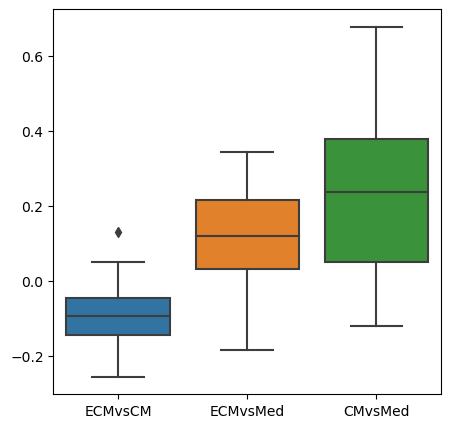

In [21]:
#ECM vs CM all samples
plt.rcParams["figure.figsize"] = (5,5)
g=sns.boxplot(data=[transformedscores_1ecm.corrwith(transformedscores_1cm,method="spearman"),transformedscores_1ecm.corrwith(transformedscores_1med,method="spearman"),transformedscores_1cm.corrwith(transformedscores_1med,method="spearman")])
g.set_xticklabels(["ECMvsCM","ECMvsMed","CMvsMed"])

In [20]:
revcan_dict["Skin Cutaneous Melanoma_Skin_Metastatic"]

['TCGA.DA.A95Z.06',
 'TCGA.EE.A29D.06',
 'TCGA.EE.A29V.06',
 'TCGA.W3.AA1O.06',
 'TCGA.EE.A2GJ.06',
 'TCGA.3N.A9WC.06',
 'TCGA.3N.A9WD.06',
 'TCGA.D9.A1JW.06',
 'TCGA.EE.A2GC.06',
 'TCGA.ER.A19F.06',
 'TCGA.DA.A1IC.06',
 'TCGA.EE.A2GP.06',
 'TCGA.FS.A4F9.06',
 'TCGA.EE.A20I.06',
 'TCGA.EE.A29S.06',
 'TCGA.ER.A19A.06',
 'TCGA.WE.A8K6.06',
 'TCGA.EE.A29L.06',
 'TCGA.EE.A29N.06',
 'TCGA.EE.A2GR.06',
 'TCGA.FR.A8YC.06',
 'TCGA.GF.A6C9.06',
 'TCGA.D3.A8GP.06',
 'TCGA.EE.A2GT.06',
 'TCGA.ER.A19C.06',
 'TCGA.RP.A693.06',
 'TCGA.D3.A2J9.06',
 'TCGA.EE.A3JE.06',
 'TCGA.YD.A9TA.06',
 'TCGA.D3.A2JF.06',
 'TCGA.D3.A5GL.06',
 'TCGA.FS.A1ZM.06',
 'TCGA.WE.A8K1.06',
 'TCGA.D3.A8GM.06',
 'TCGA.EE.A2MC.06',
 'TCGA.GN.A4U4.06',
 'TCGA.QB.AA9O.06',
 'TCGA.D3.A1Q9.06',
 'TCGA.EE.A184.06',
 'TCGA.EE.A2MS.06',
 'TCGA.EE.A3J4.06',
 'TCGA.3N.A9WB.06',
 'TCGA.EB.A5UL.06',
 'TCGA.EE.A2A2.06',
 'TCGA.EE.A2MU.06',
 'TCGA.EE.A3J5.06',
 'TCGA.FS.A1ZY.06',
 'TCGA.GN.A4U9.06',
 'TCGA.RP.A694.06',
 'TCGA.W3.AA1R.06',


In [22]:
module_correlation_ecm_cm={}
for mtype in matrixlist:
    module_correlation_ecm_cm[mtype]=transformedscores_1ecm.loc[transformedscores_1ecm.index.intersection(revcan_dict[mtype])].corrwith(transformedscores_1cm.loc[transformedscores_1cm.index.intersection(revcan_dict[mtype])],method='spearman')

In [23]:
mcorrecm_cmdf=pd.concat(module_correlation_ecm_cm,axis=1)

In [24]:
mboxcorr=mcorrecm_cmdf.stack().reset_index()

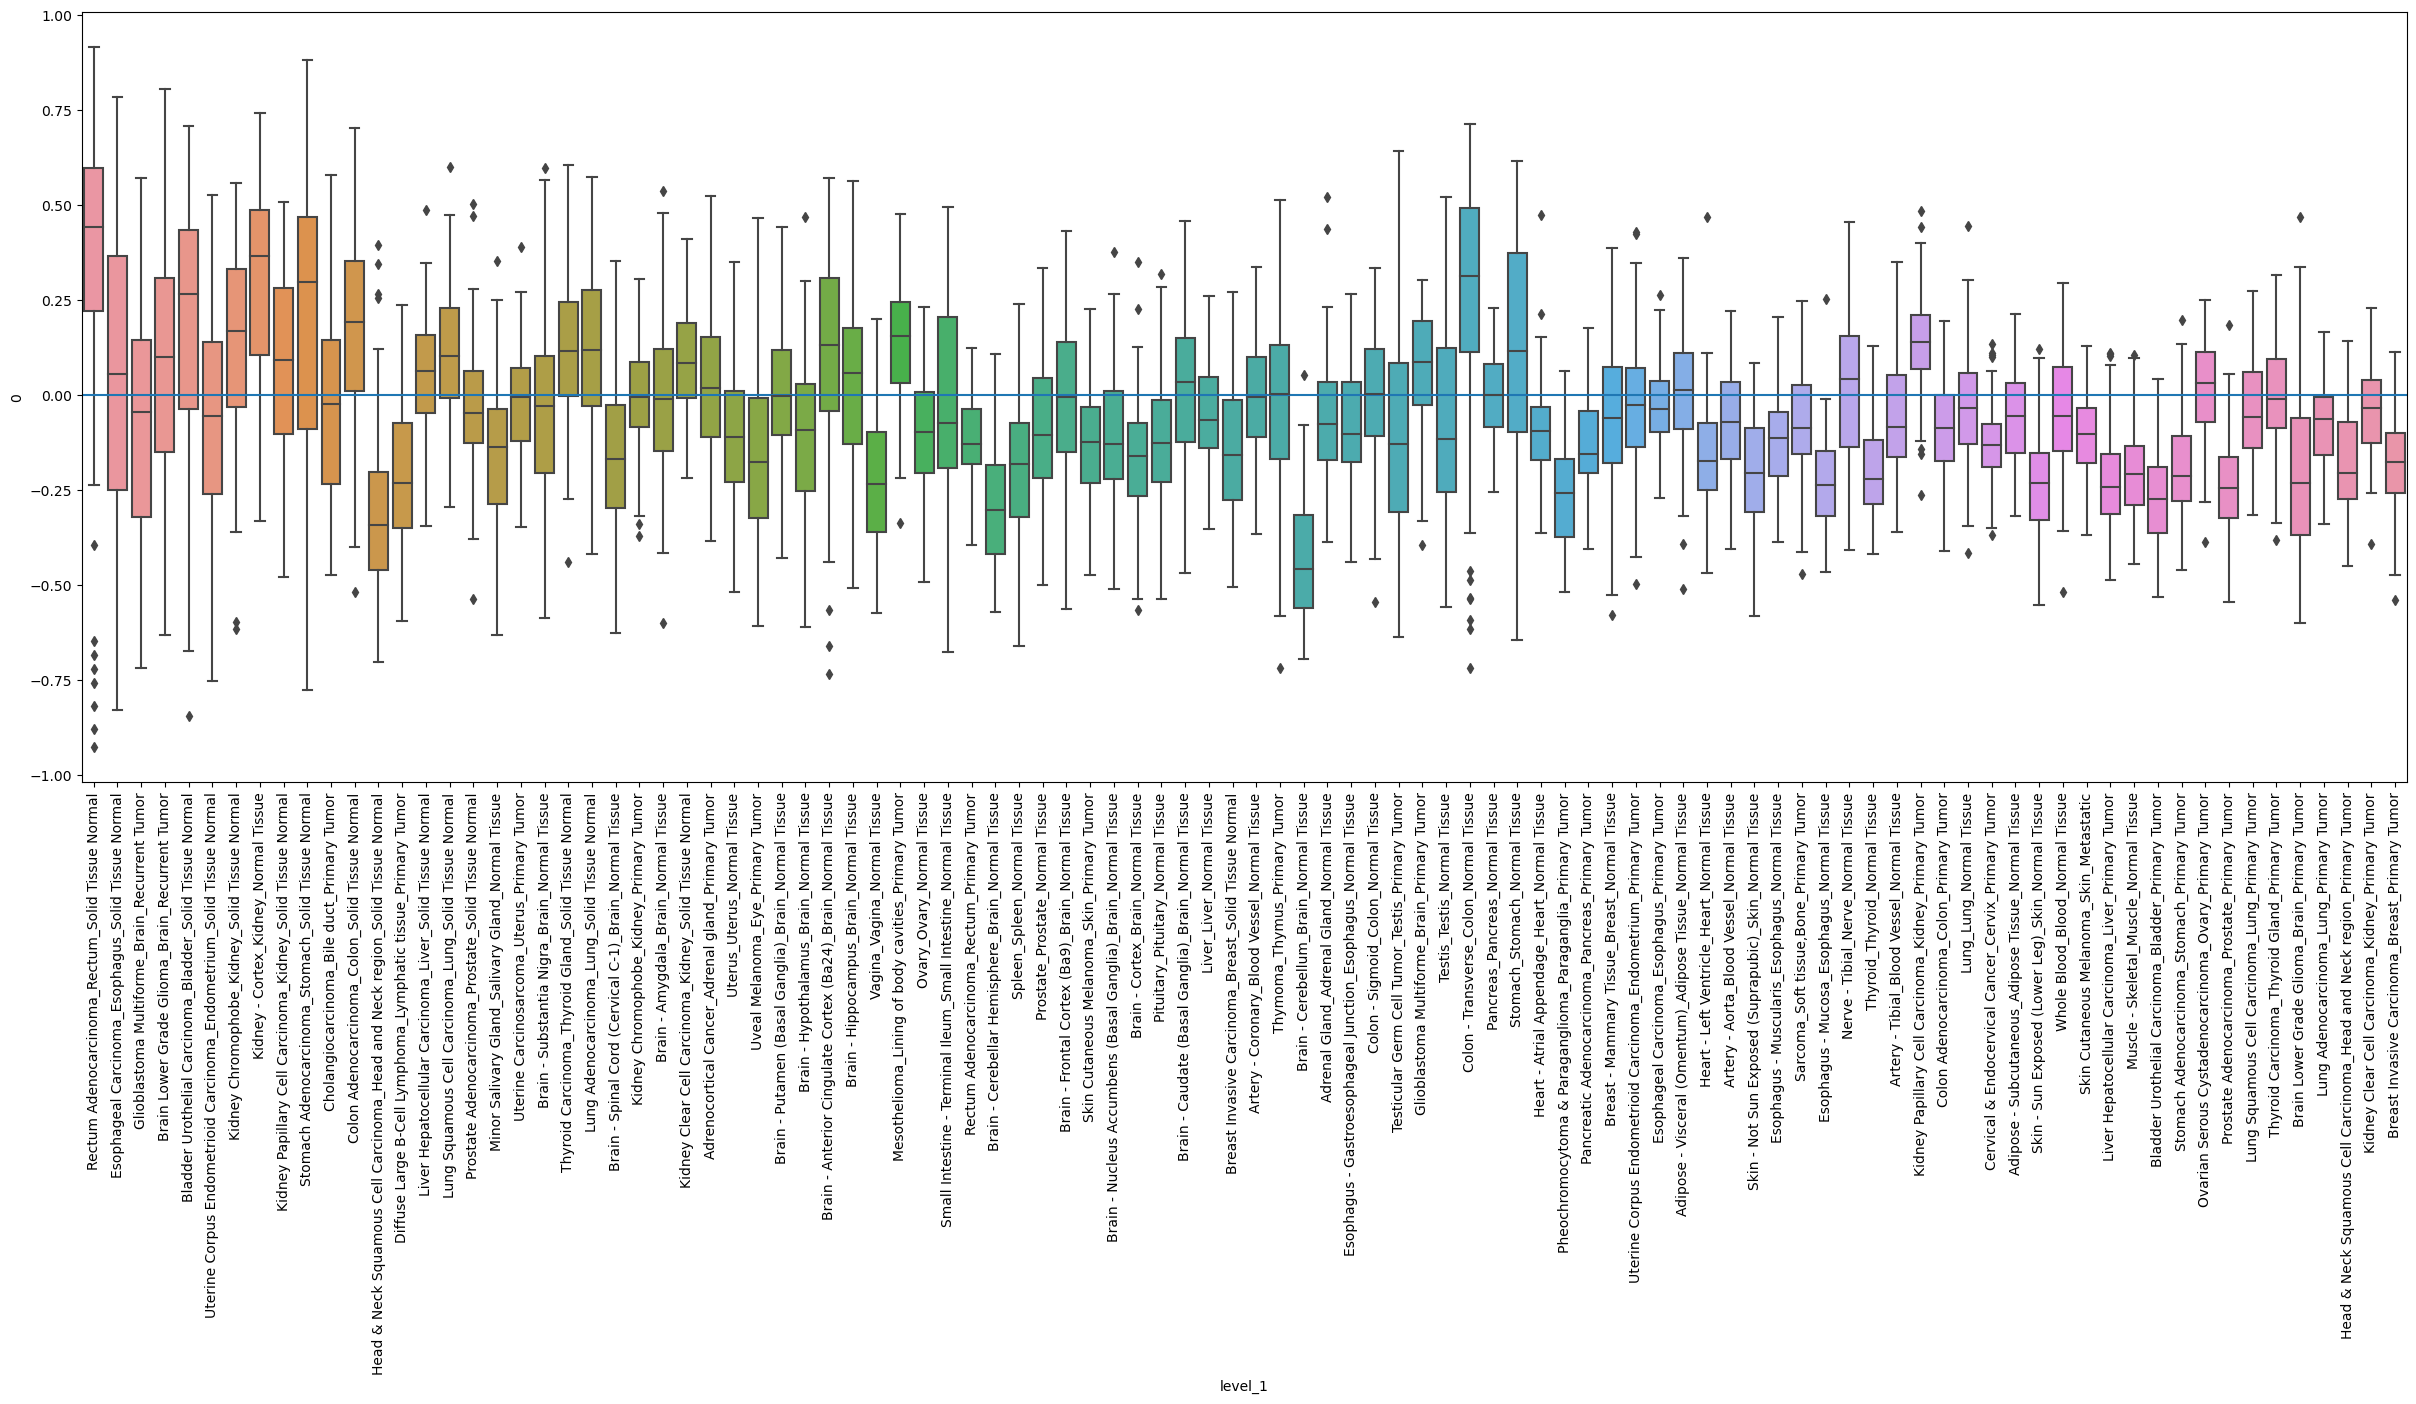

In [25]:
plt.rcParams["figure.figsize"] = (30,10)
g=sns.boxplot(data=mboxcorr,x="level_1",y=0)
g.set_xticklabels(g.get_xticklabels(), rotation=90)
g.axhline(0)

In [26]:
mboxcorr["stype"]=mboxcorr["level_1"].map(sthued)
mboxcorr["proj"]=mboxcorr["level_1"].map(invcombgenex)
mboxcorr.head()

,level_0,level_1,0,stype,proj
0,module_0,Rectum Adenocarcinoma_Rectum_Solid Tissue Normal,0.527273,NAT,TCGA-READ
1,module_0,Esophageal Carcinoma_Esophagus_Solid Tissue No...,-0.186813,NAT,TCGA-ESCA
2,module_0,Glioblastoma Multiforme_Brain_Recurrent Tumor,-0.071429,RT,TCGA-GBM2
3,module_0,Brain Lower Grade Glioma_Brain_Recurrent Tumor,-0.028571,RT,TCGA-LGG2
4,module_0,Bladder Urothelial Carcinoma_Bladder_Solid Tis...,0.422807,NAT,TCGA-BLCA


In [27]:
mboxcorr[mboxcorr["proj"]=="TCGA-SKCM1"]

,level_0,level_1,0,stype,proj
84,module_0,Skin Cutaneous Melanoma_Skin_Metastatic,-0.134566,MT,TCGA-SKCM1
182,module_1,Skin Cutaneous Melanoma_Skin_Metastatic,-0.103455,MT,TCGA-SKCM1
280,module_2,Skin Cutaneous Melanoma_Skin_Metastatic,-0.102750,MT,TCGA-SKCM1
378,module_3,Skin Cutaneous Melanoma_Skin_Metastatic,-0.138736,MT,TCGA-SKCM1
476,module_4,Skin Cutaneous Melanoma_Skin_Metastatic,-0.324298,MT,TCGA-SKCM1
...,...,...,...,...,...
7630,module_123,Skin Cutaneous Melanoma_Skin_Metastatic,-0.212445,MT,TCGA-SKCM1
7728,module_125,Skin Cutaneous Melanoma_Skin_Metastatic,-0.103302,MT,TCGA-SKCM1
7826,module_129,Skin Cutaneous Melanoma_Skin_Metastatic,0.041288,MT,TCGA-SKCM1
7924,module_133,Skin Cutaneous Melanoma_Skin_Metastatic,-0.136732,MT,TCGA-SKCM1


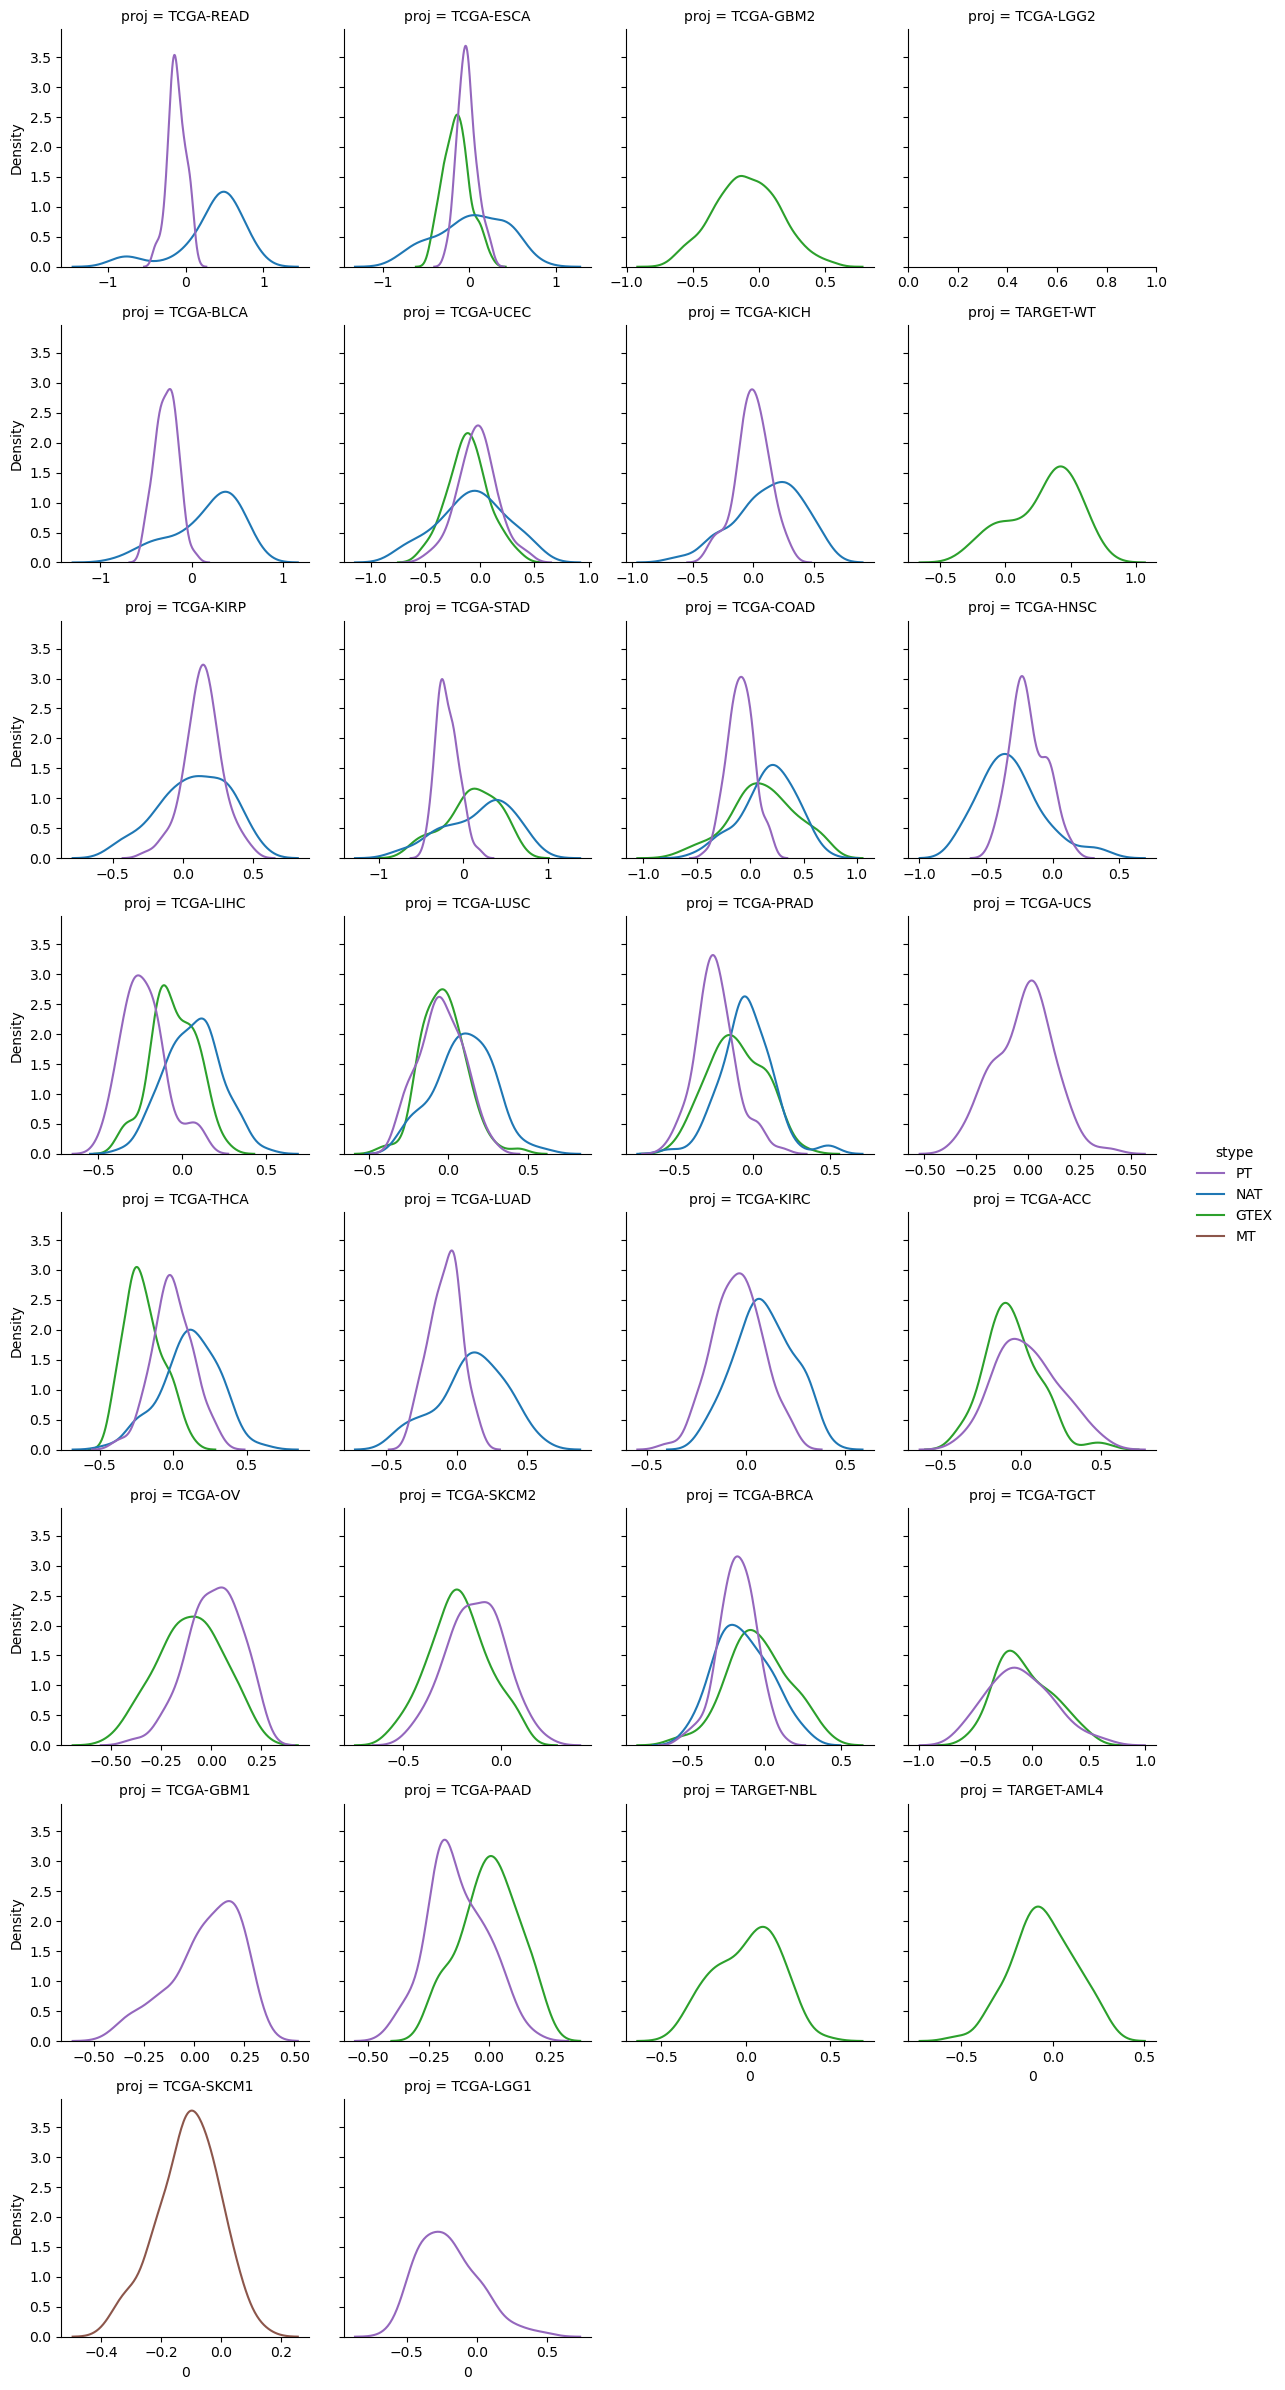

In [28]:
unique = mboxcorr["stype"].unique()
palette = dict(zip(unique, sns.color_palette(n_colors=len(unique))))
g=sns.displot(data=mboxcorr,hue="stype",col="proj",x=0,kind="kde",palette=palette,height=3,aspect=1,col_wrap=4,hue_order=["PT","NAT","GTEX","MT"],common_norm=False,facet_kws={"legend_out":True,"sharex":False})

In [29]:
testcr=pd.concat([transformedscores_1ecm,transformedscores_1cm],axis=1,keys=["ecm","cm"])
testcr.head()

ecm                                         \
                    module_0     module_1     module_2     module_3   
TCGA.V5.AASX.11  -771.502079 -1005.057988 -1153.809170 -1079.139590   
TCGA.IG.A3I8.11  1387.842924   943.058575  1761.794689  1269.859327   
TCGA.L5.A4OG.11  -297.143961  -479.239669  -632.478979  -557.474548   
TCGA.L5.A4OQ.11  -216.673190   -28.327959  -166.256429  -110.284900   
TCGA.L5.A4OR.11   -98.172981  -294.849544  -428.957284  -403.659302   

                                                                     \
                    module_4     module_5     module_6     module_8   
TCGA.V5.AASX.11  -912.043063 -1369.708701 -2085.550746 -1979.542027   
TCGA.IG.A3I8.11  1165.059808  1531.661326  1969.144577  1474.577941   
TCGA.L5.A4OG.11  -457.198831  -832.577179   -71.308374  -358.085194   
TCGA.L5.A4OQ.11  -118.816113   -73.995033  -568.532800  -217.611446   
TCGA.L5.A4OR.11  -300.361428  -401.760431   299.678006   -93.779725   

                                           ...          cm              \
                    module_9    module_10  ...  module_126  module_127   
TCGA.V5.AASX.11 -1344.622559 -1469.688057  ...  300.263933  381.169938   
TCGA.IG.A3I8.11  2509.234776  1226.540034  ...  132.322504  114.256607   
TCGA.L5.A4OG.11  -700.596415  -766.363595  ...  -22.626406   91.582022   
TCGA.L5.A4OQ.11  -278.412533    30.111487  ...   46.444267  -28.943917   
TCGA.L5.A4OR.11  -602.113078  -284.825284  ... -212.870414 -299.470092   

                                                                             \
                 module_128  module_129  module_130  module_131  module_132   
TCGA.V5.AASX.11    2.719053  611.917837  300.478791  647.299472  243.176935   
TCGA.IG.A3I8.11 -177.892892  288.783892  -32.898935  -31.309238 -323.647747   
TCGA.L5.A4OG.11  135.063532 -174.011771   77.468308    9.409538  -17.180992   
TCGA.L5.A4OQ.11 -205.463885   70.746129   29.665022   45.990303   87.368103   
TCGA.L5.A4OR.11 -100.955076 -253.595478 -419.701009 -375.584397  -49.684067   

                                                     
                 module_133  module_134  module_135  
TCGA.V5.AASX.11 -134.018526  882.738569 -623.894657  
TCGA.IG.A3I8.11  541.970900 -122.569814 -800.709865  
TCGA.L5.A4OG.11 -274.113315  283.549147  -85.169953  
TCGA.L5.A4OQ.11   95.038744 -122.227975  155.809879  
TCGA.L5.A4OR.11  -25.358599 -502.979629  227.011210  

[5 rows x 214 columns]

In [30]:
all_correlation_ecm_cm={}
for mtype in matrixlist:
    corrtcr=testcr.loc[testcr.index.intersection(revcan_dict[mtype])].corr(method="spearman")
    corrtcr.drop(corrtcr.index[corrtcr.index.get_level_values(0)=="ecm"],inplace=True)
    corrtcr.drop(corrtcr.columns[corrtcr.columns.get_level_values(0)=="cm"],inplace=True,axis=1)
    all_correlation_ecm_cm[mtype]=corrtcr.copy()

<AxesSubplot:>

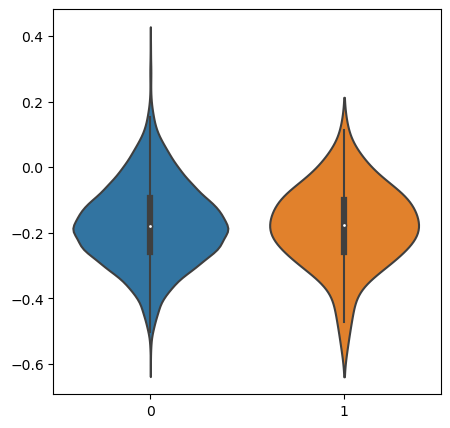

In [31]:
plt.rcParams['figure.figsize'] = [5, 5]
sns.violinplot(data=[all_correlation_ecm_cm["Breast Invasive Carcinoma_Breast_Primary Tumor"].stack().reset_index()["ecm"],mcorrecm_cmdf["Breast Invasive Carcinoma_Breast_Primary Tumor"]])

In [32]:
test = {k: sthued[k] for k in all_correlation_ecm_cm if k in sthued}
clrs2=sns.color_palette("Set1",len(invsth))
glut=dict(zip(list(invsth.keys()), list(clrs2.as_hex())))
cmpas={k: glut[v] for k,v in test.items()}

In [33]:
kdeplotallcorr=pd.DataFrame({f:all_correlation_ecm_cm[f].stack().reset_index()["ecm"] for f in all_correlation_ecm_cm},)

<AxesSubplot:ylabel='Density'>

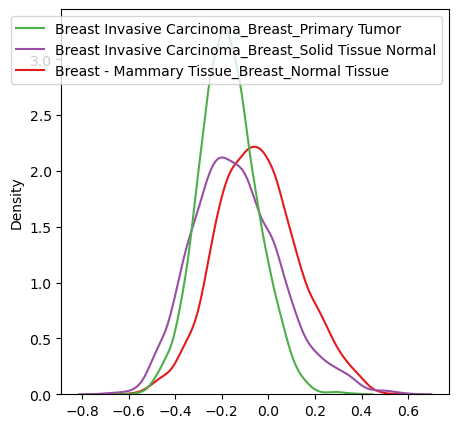

In [34]:
sns.kdeplot(data=kdeplotallcorr[combgenexfiles["TCGA-BRCA"]],palette=cmpas,common_norm=False)

<AxesSubplot:xlabel='None-None', ylabel='None-None'>

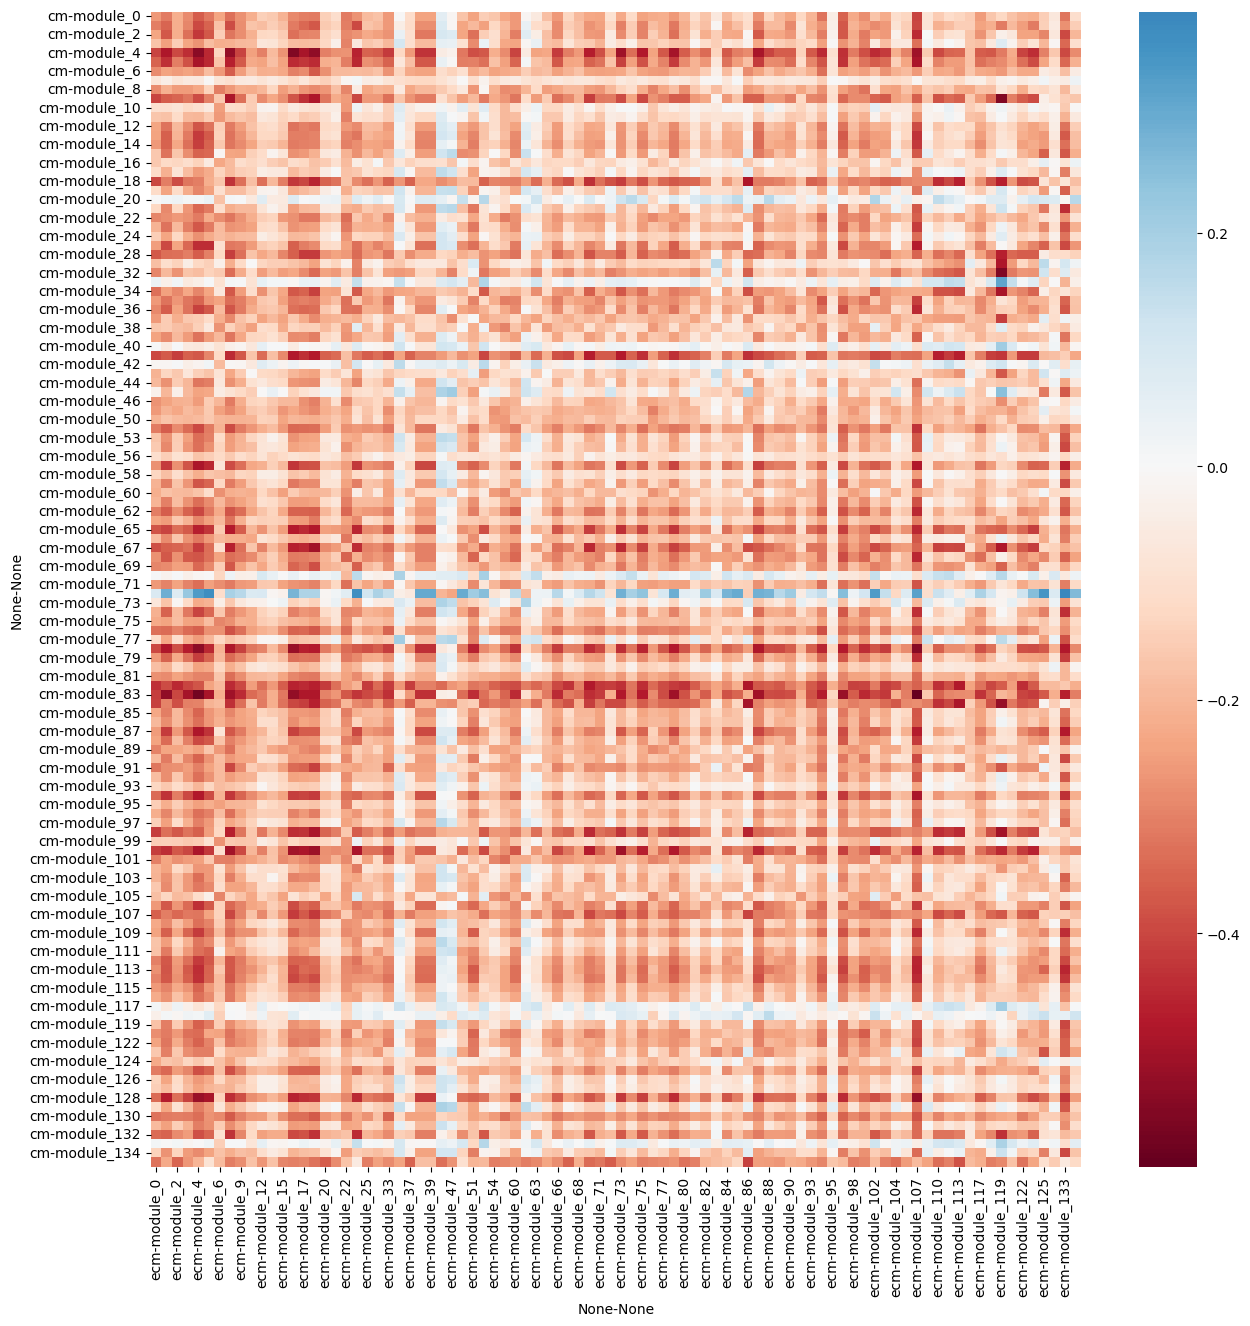

In [35]:
plt.rcParams['figure.figsize'] = [15, 15]
sns.heatmap(all_correlation_ecm_cm["Breast Invasive Carcinoma_Breast_Primary Tumor"],cmap="RdBu",center=0)

<AxesSubplot:xlabel='None-None', ylabel='None-None'>

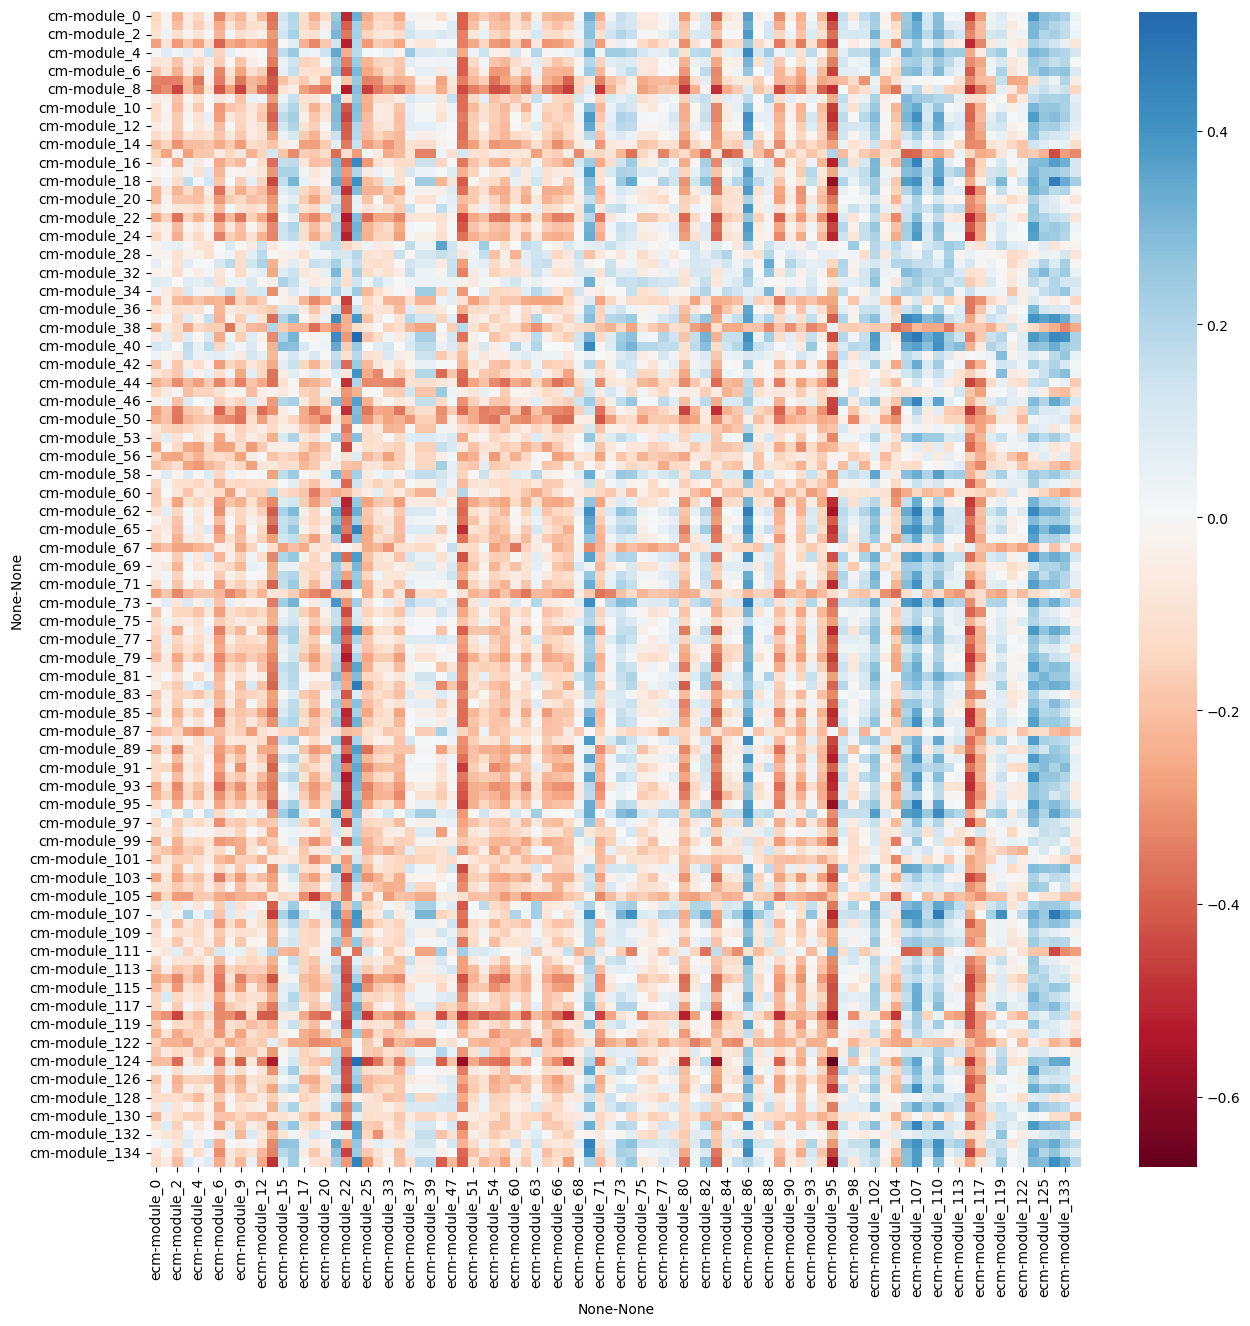

In [36]:
plt.rcParams['figure.figsize'] = [15, 15]
sns.heatmap(all_correlation_ecm_cm["Breast - Mammary Tissue_Breast_Normal Tissue"],cmap="RdBu",center=0)

<AxesSubplot:xlabel='None-None', ylabel='None-None'>

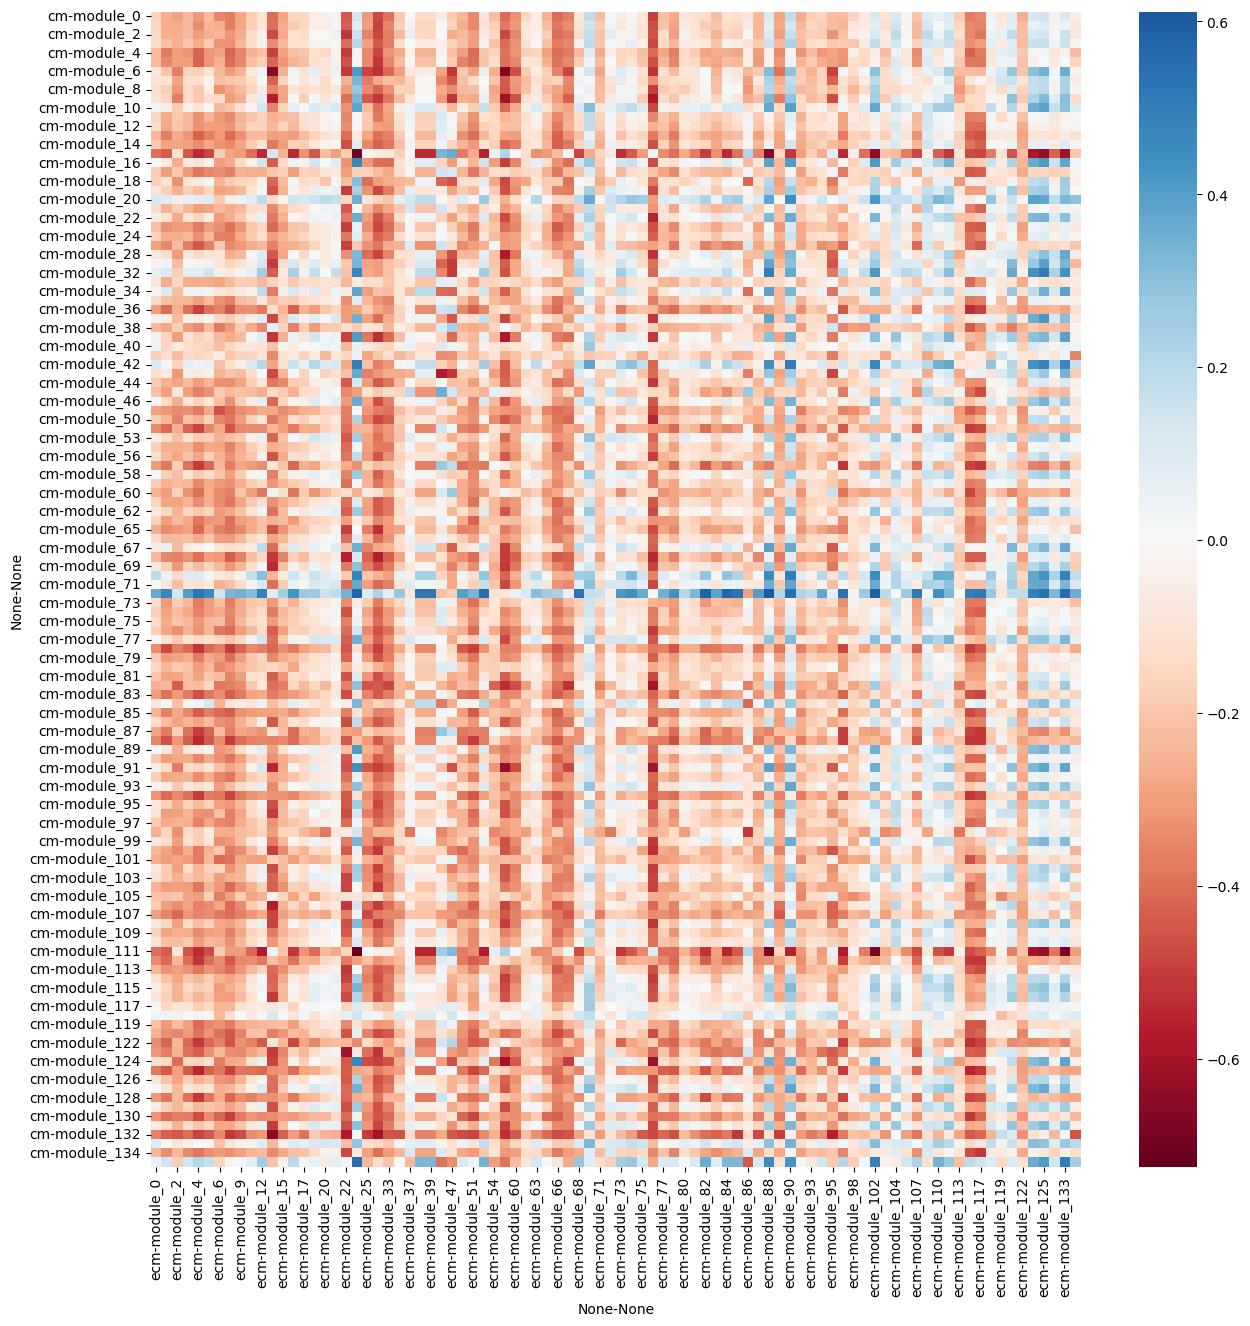

In [37]:
plt.rcParams['figure.figsize'] = [15, 15]
sns.heatmap(all_correlation_ecm_cm["Breast Invasive Carcinoma_Breast_Solid Tissue Normal"],cmap="RdBu",center=0)

In [4]:
modecmdict={}
for line in open(genelistdata+"supmod_ecm.tsv"):
    line=line.strip()
    cols=line.split("\t")
    modecmdict[cols[0]]=cols[1:]
modcmdict={}
for line in open(genelistdata+"supmod_cm.tsv"):
    line=line.strip()
    cols=line.split("\t")
    modcmdict[cols[0]]=cols[1:]
modmeddict={}
for line in open(genelistdata+"supmod_med.tsv"):
    line=line.strip()
    cols=line.split("\t")
    modmeddict[cols[0]]=cols[1:]

CPU times: user 6.16 s, sys: 364 ms, total: 6.52 s
Wall time: 6.58 s


(-1.0, 1.0)

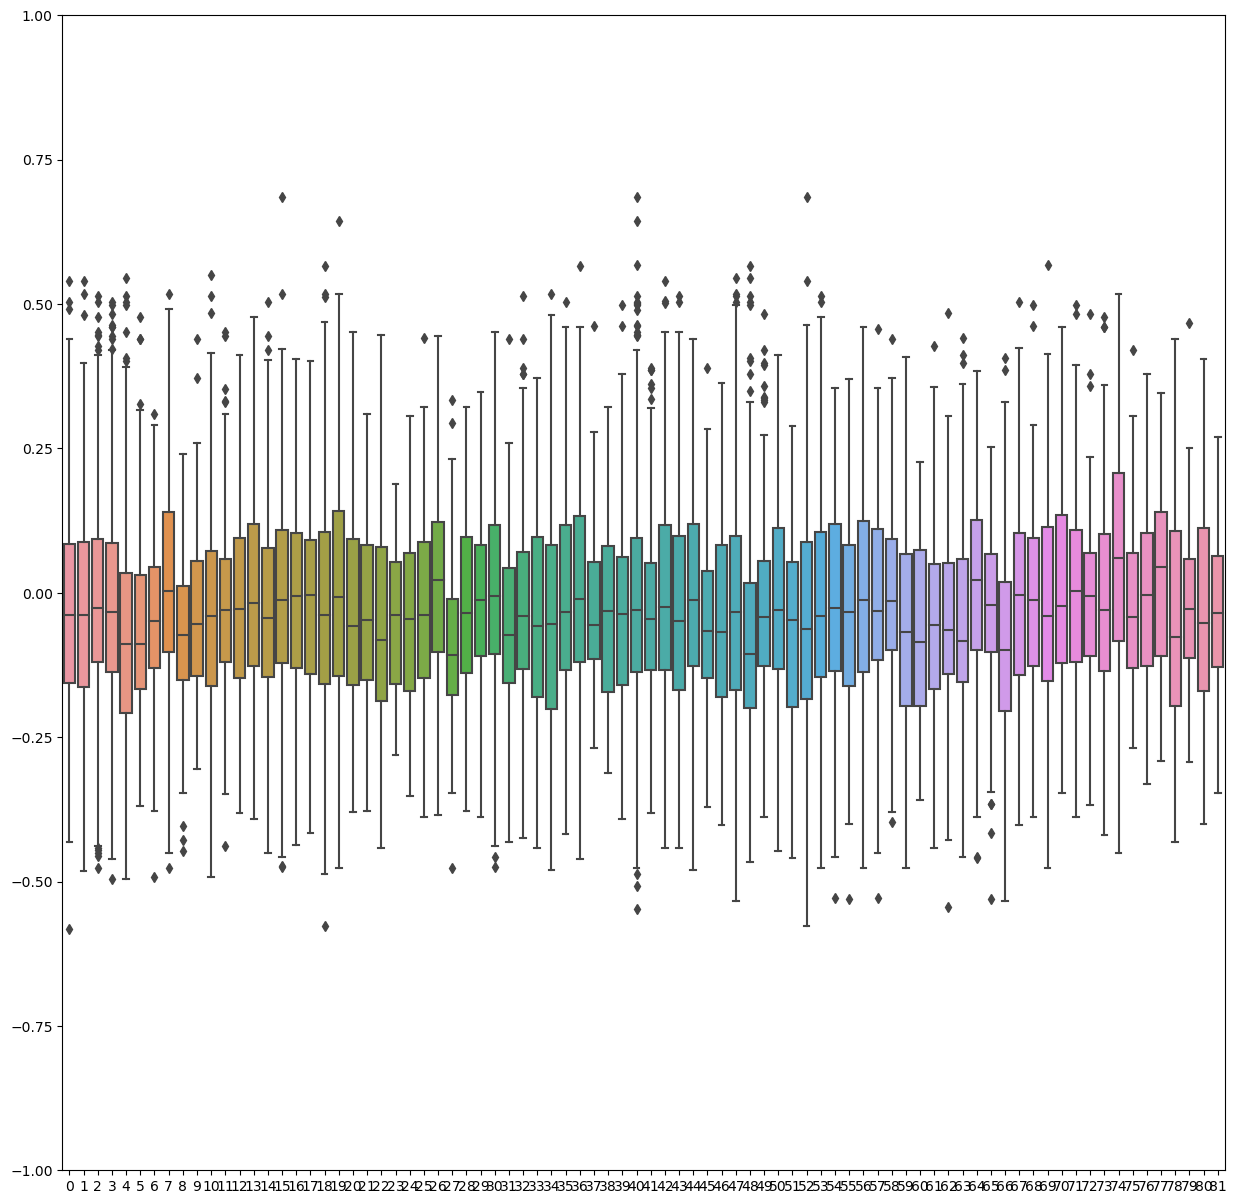

In [39]:
%%time
with gzip.open("Breast Invasive Carcinoma_Breast_Primary Tumor_geneexp.tsv_parcorr.pkl.gz","rb") as pkl:
    corralltest=pickle.load(pkl)
sns.boxplot(data=[corralltest.loc[corralltest.index.intersection(modecmdict[modind]).tolist(),corralltest.index.intersection(modcmdict[modind]).tolist()].stack() for modind in transformedscores_1cm.columns.intersection(transformedscores_1ecm.columns).tolist()])
plt.ylim(-1,1)

<AxesSubplot:>

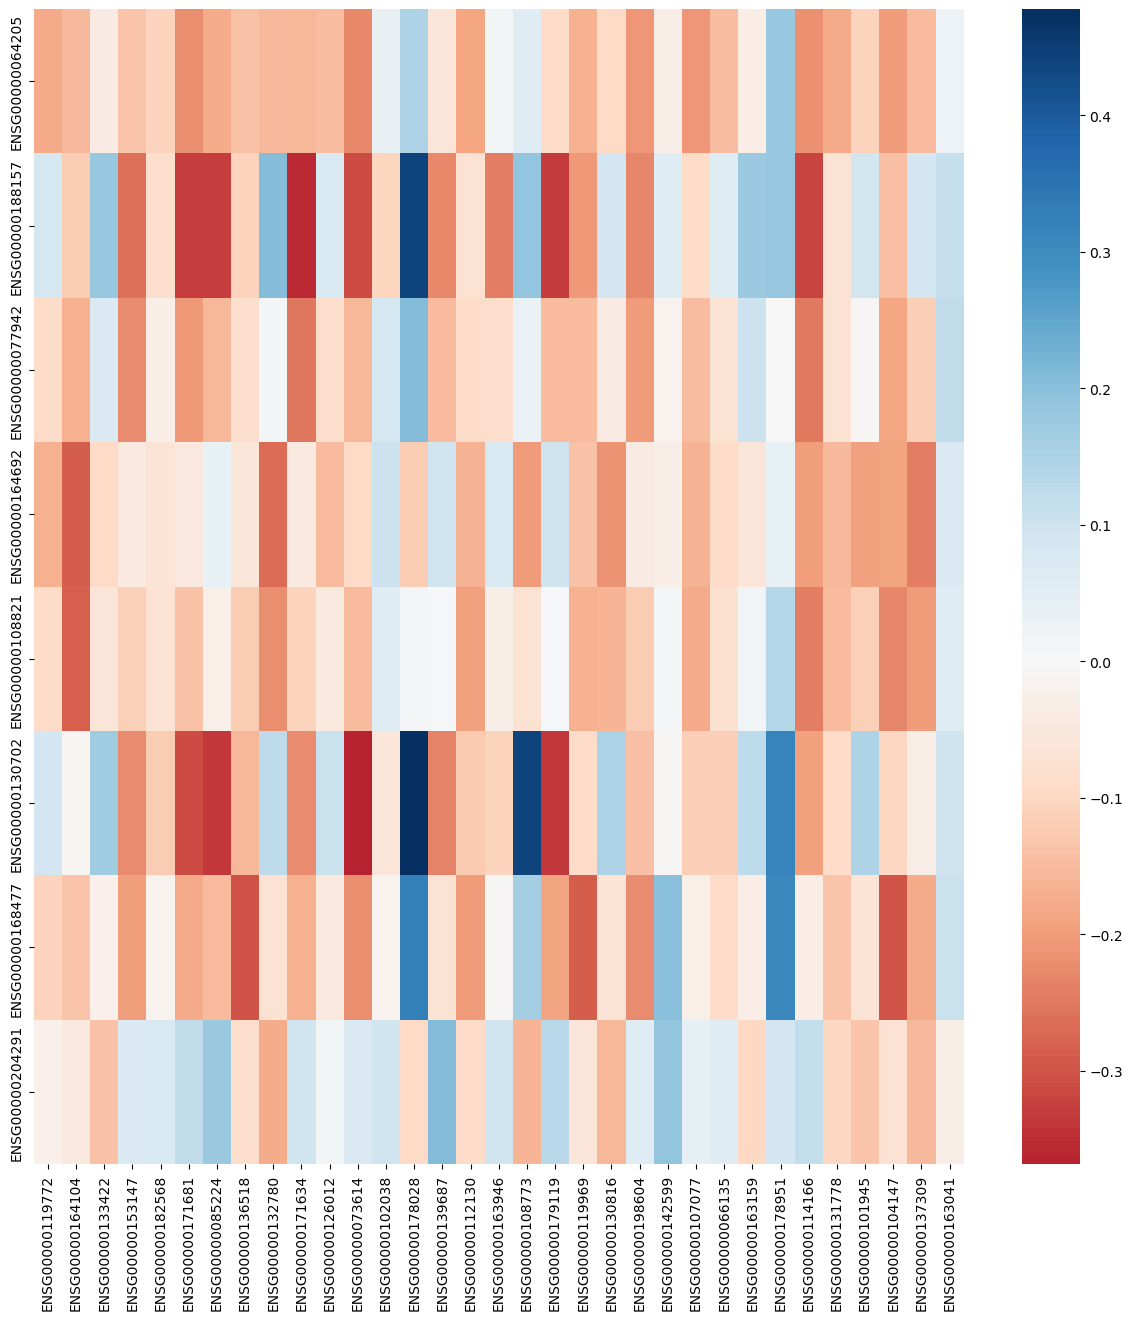

In [40]:
sns.heatmap(corralltest.loc[corralltest.index.intersection(modecmdict["module_5"]).tolist(),corralltest.index.intersection(modcmdict["module_5"]).tolist()],cmap="RdBu",center=0)

In [42]:
gtexmetadata1=pd.read_csv(UCSCtoilpath+"gtex_info/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt",sep="\t",index_col=0)
gtexmetadata1["subid"]=gtexmetadata1.index.str.split("-").str[0:2]
gtexmetadata1["subid"]=gtexmetadata1["subid"].str.join("-")
gtexmetadata2=pd.read_csv(UCSCtoilpath+"gtex_info/GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt",sep="\t",index_col=0)
gtexmetadata = gtexmetadata1.merge(gtexmetadata2, left_on='subid', right_on="SUBJID",right_index=True, how='inner', suffixes=('_1', '_2'))
gtexmetadata[["AGE","SMTSISCH","SEX"]]

,AGE,SMTSISCH,SEX
SAMPID,,,
GTEX-1117F-0003-SM-58Q7G,60-69,1188.0,2
GTEX-1117F-0003-SM-5DWSB,60-69,1188.0,2
GTEX-1117F-0003-SM-6WBT7,60-69,1188.0,2
GTEX-1117F-0011-R10a-SM-AHZ7F,60-69,1193.0,2
GTEX-1117F-0011-R10b-SM-CYKQ8,60-69,1193.0,2
...,...,...,...
K-562-SM-E9EZC,50-59,NaN,2
K-562-SM-E9EZI,50-59,NaN,2
K-562-SM-E9EZO,50-59,NaN,2


In [43]:
clindata=pd.read_csv(GDCPANCANpath+"GDC-PANCAN.basic_phenotype.tsv.gz", sep="\t", index_col=0)
clindata.index=clindata.index.str[:-1]
clindata = (clindata.reset_index()
        .drop_duplicates(subset='sample', keep='first')
        .set_index('sample'))
clindata["Gender"]=clindata["Gender"].str.replace("Male","1")
clindata["Gender"]=clindata["Gender"].str.replace("Female","2")
clindata["Gender"]=clindata["Gender"].str.replace("not reported|Unknown","nan")
clindata["Gender"]=clindata["Gender"].astype("float")

/tmp/ipykernel_145164/1977528097.py:8: FutureWarning: The default value of regex will change from True to False in a future version.
  clindata["Gender"]=clindata["Gender"].str.replace("not reported|Unknown","nan")


In [44]:
gtexmetadata.index=gtexmetadata.index.str.replace("-",".",regex=False)
clindata.index=clindata.index.str.replace("-",".",regex=False)

In [45]:
allfiles=[]
for gfile in os.listdir(ECMprojpath+"subtype_purity/BG_deconvolution_without_noncoding_v2/"):
    allfiles.append(pd.read_csv(ECMprojpath+"subtype_purity/BG_deconvolution_without_noncoding_v2/"+gfile,sep="\t",index_col=0))
for gfile in os.listdir(ECMprojpath+"subtype_purity/Kassandra_TCGA/"):
    allfiles.append(pd.read_csv(ECMprojpath+"subtype_purity/Kassandra_TCGA/"+gfile,sep="\t",index_col=0))

In [46]:
deconv=pd.concat(allfiles,join='inner', axis=1)
deconv.columns=deconv.columns.str.replace("-",".",regex=False)
deconv1=deconv.loc["Other"].transpose()
p1=pd.concat([deconv1,gtexmetadata[["SMTSISCH","AGE","SEX","DTHHRDY"]]],join="inner",axis=1)
p2=pd.concat([deconv1,clindata[["Age at Diagnosis in Years","Gender"]]],join="inner",axis=1)

In [55]:
#test = {k: sthued[k] for k in all_correlation_ecm_cm}
#clrs2=sns.color_palette("Set1",len(invsth))
glut=dict(zip(list(invsth.keys()), list(clrs2.as_hex())))
cmpas={k: glut[v] for k,v in test.items()}

In [ ]:
plt.rcParams['figure.figsize'] = [10, 10]
kdeplotallcorr=pd.DataFrame({f:all_correlation_ecm_cm[f].stack().reset_index()["ecm"] for f in all_correlation_ecm_cm},)
sns.kdeplot(data=kdeplotallcorr,palette=cmpas,legend=False)

In [ ]:
from collections import OrderedDict
test=mcorrecm_cmdf.dropna(how="all").dropna(axis=1,how="all").columns.map(sthued)
clrs2=sns.color_palette("Set1",len(invsth))
glut=dict(zip(list(invsth.keys()), list(clrs2.as_hex())))
cmpas=test.map(glut)
from matplotlib.patches import Patch
sns.clustermap(mcorrecm_cmdf.dropna(how="all").dropna(axis=1,how="all"),figsize=(30,15),row_cluster=False,col_cluster=False,cmap="RdBu",center=0)
#handles2 = [Patch(facecolor=glut[name]) for name in glut]
plt.legend(glut, title='Tissue type',bbox_to_anchor=(1, 1),bbox_transform=plt.gcf().transFigure, loc='upper right')

In [ ]:
plt.rcParams["figure.figsize"] = (10,3)
sns.heatmap(mcorrecm_cmdf.dropna(how="all").dropna(axis=1,how="all")[mcorrecm_cmdf.dropna(how="all").dropna(axis=1,how="all").columns.intersection(combgenexfiles["TCGA-ACC"])].transpose(),cmap="RdBu",center=0)

CPU times: user 6.45 s, sys: 414 ms, total: 6.86 s
Wall time: 7.2 s


(-1.0, 1.0)

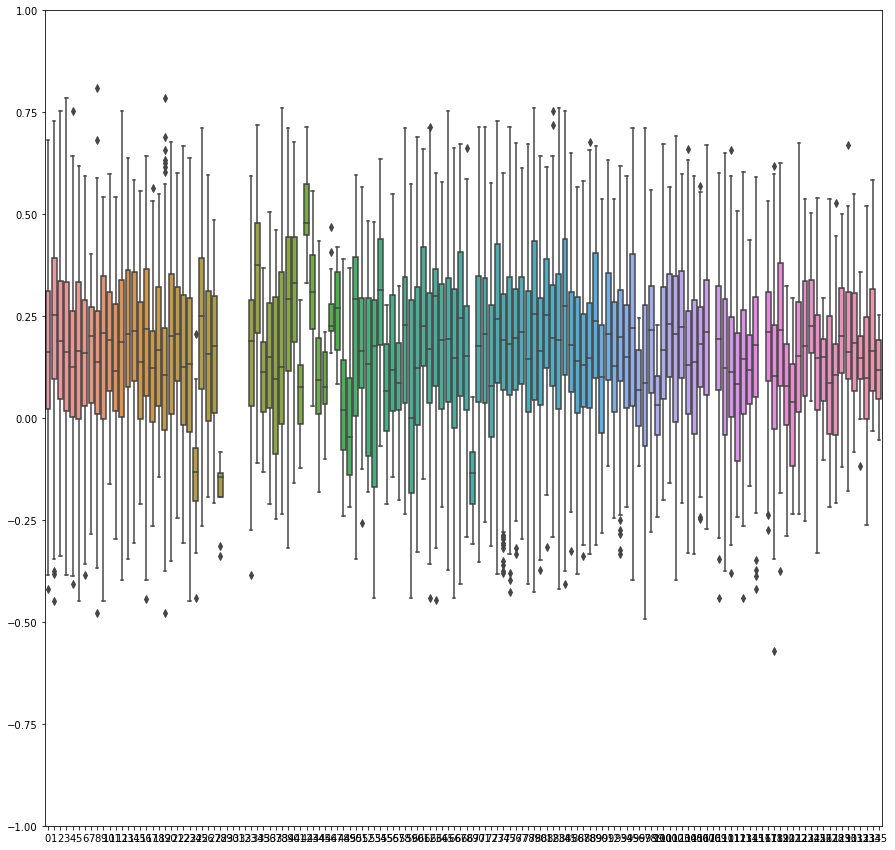

In [8]:
%%time
plt.rcParams['figure.figsize'] = [15, 15]

with gzip.open("Adrenocortical Cancer_Adrenal gland_Primary Tumor_geneexp.tsv_parcorr.pkl.gz","rb") as pkl:
    corralltest=pickle.load(pkl)
sns.boxplot(data=[corralltest.loc[corralltest.index.intersection(modecmdict[modind]).tolist(),corralltest.index.intersection(modcmdict[modind]).tolist()].stack() for modind in modecmdict])
plt.ylim(-1,1)

CPU times: user 7.37 s, sys: 385 ms, total: 7.76 s
Wall time: 8.88 s


(-1.0, 1.0)

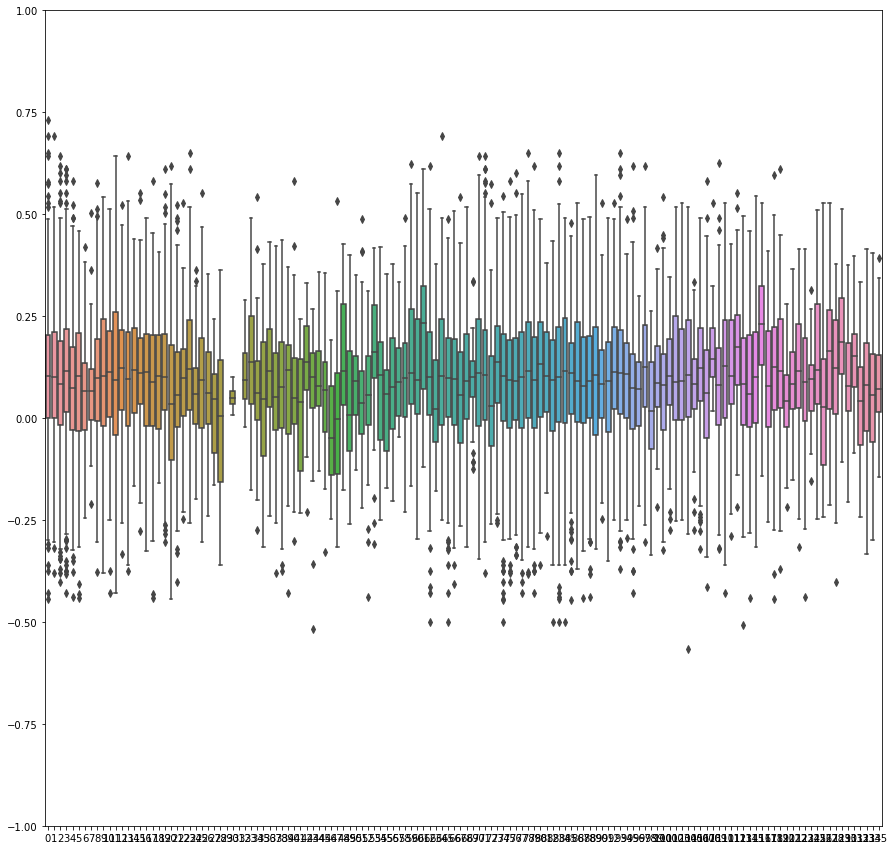

In [9]:
%%time
with gzip.open("Adrenal Gland_Adrenal Gland_Normal Tissue_geneexp.tsv_parcorr.pkl.gz","rb") as pkl:
    corralltest=pickle.load(pkl)
sns.boxplot(data=[corralltest.loc[corralltest.index.intersection(modecmdict[modind]).tolist(),corralltest.index.intersection(modcmdict[modind]).tolist()].stack() for modind in modecmdict])
plt.ylim(-1,1)

<AxesSubplot:>

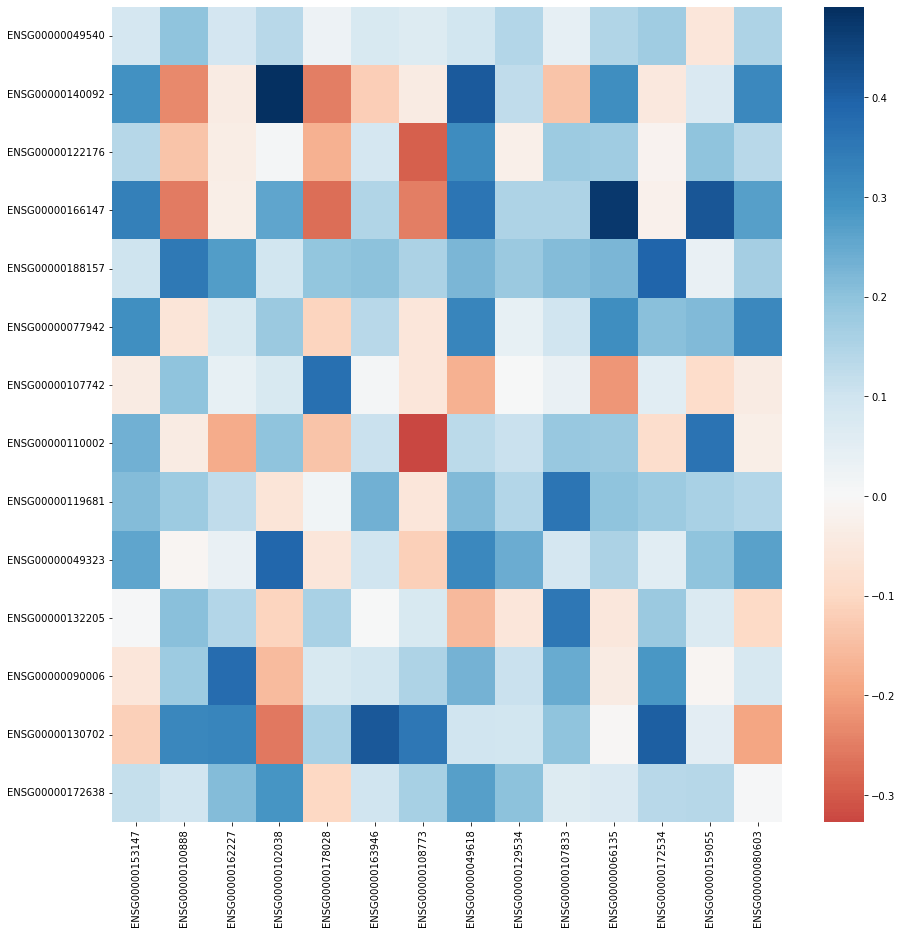

In [10]:
sns.heatmap(corralltest.loc[corralltest.index.intersection(modecmdict["module_16"]).tolist(),corralltest.index.intersection(modcmdict["module_16"]).tolist()],cmap="RdBu",center=0)

In [ ]:
plt.rcParams["figure.figsize"] = (10,3)
sns.heatmap(mcorrecm_cmdf.dropna(how="all").dropna(axis=1,how="all")[mcorrecm_cmdf.dropna(how="all").dropna(axis=1,how="all").columns.intersection(combgenexfiles["TCGA-BRCA"])].transpose(),cmap="RdBu",center=0)

In [ ]:
plt.rcParams["figure.figsize"] = (10,3)
sns.heatmap(mcorrecm_cmdf.dropna(how="all").dropna(axis=1,how="all")[mcorrecm_cmdf.dropna(how="all").dropna(axis=1,how="all").columns.intersection(combgenexfiles["TCGA-LIHC"])].transpose(),cmap="RdBu",center=0)

In [ ]:
test = {k: sthued[k] for k in all_correlation_ecm_cm}
clrs2=sns.color_palette("Set1",len(invsth))
glut=dict(zip(list(invsth.keys()), list(clrs2.as_hex())))
cmpas={k: glut[v] for k,v in test.items()}

In [ ]:
plt.rcParams['figure.figsize'] = [10, 10]
sns.kdeplot(data=kdeplotallcorr[combgenexfiles["TCGA-LUSC"]],palette=cmpas,common_norm=False)

In [ ]:
plt.rcParams['figure.figsize'] = [10, 10]
sns.kdeplot(data=kdeplotallcorr[combgenexfiles["TCGA-BRCA"]],palette=cmpas,common_norm=False)

In [ ]:
plt.rcParams['figure.figsize'] = [5, 5]
sns.boxplot(data=[all_correlation_ecm_cm["Breast Invasive Carcinoma_Breast_Primary Tumor"].stack().reset_index()["ecm"],mcorrecm_cmdf["Breast Invasive Carcinoma_Breast_Primary Tumor"]])

In [ ]:
%%time
with gzip.open("Breast Invasive Carcinoma_Breast_Primary Tumor_geneexp.tsv_parcorr.pkl.gz","rb") as pkl:
    corralltest=pickle.load(pkl)
plt.rcParams['figure.figsize'] = [15, 15]
sns.heatmap(corralltest.loc[corralltest.index.intersection(allmod_ecmgenesl),corralltest.index.intersection(allmod_cmgenesl)],cmap="RdBu",center=0)

In [ ]:
sns.boxplot(data=corralltest.loc[corralltest.index.intersection(allmod_ecmgenesl),corralltest.index.intersection(allmod_cmgenesl)].stack().reset_index())

In [ ]:
universeecmcmmed=medgenesl+allmod_cmgenesl+allmod_ecmgenesl

In [ ]:
%%time
allgxg_ecmxcm_corr={}
for file in os.listdir():
    if file.endswith(".tsv_parcorr.pkl.gz"):
        with gzip.open(file,"rb") as pkl:
            corralltest=pickle.load(pkl)
        allgxg_ecmxcm_corr[file[:-27]]=corralltest.loc[corralltest.index.intersection(universeecmcmmed),corralltest.index.intersection(universeecmcmmed)].copy()

In [ ]:
allgxg_ecmxcm_corrdf=pd.concat(allgxg_ecmxcm_corr,axis=1)
allgxg_ecmxcm_corrdf.drop(allgxg_ecmxcm_corrdf.index.intersection(allmod_ecmgenesl+medgenesl),axis=1,level=1,inplace=True)
allgxg_ecmxcm_corrdf.drop(allgxg_ecmxcm_corrdf.index.intersection(allmod_cmgenesl+medgenesl),inplace=True)
allgxg_ecmxecm_corrdf=pd.concat(allgxg_ecmxcm_corr,axis=1)
allgxg_ecmxecm_corrdf.drop(allgxg_ecmxecm_corrdf.index.intersection(allmod_cmgenesl+medgenesl),axis=1,level=1,inplace=True)
allgxg_ecmxecm_corrdf.drop(allgxg_ecmxecm_corrdf.index.intersection(allmod_cmgenesl+medgenesl),inplace=True)
allgxg_cmxcm_corrdf=pd.concat(allgxg_ecmxcm_corr,axis=1)
allgxg_cmxcm_corrdf.drop(allgxg_cmxcm_corrdf.index.intersection(allmod_ecmgenesl+medgenesl),axis=1,level=1,inplace=True)
allgxg_cmxcm_corrdf.drop(allgxg_cmxcm_corrdf.index.intersection(allmod_ecmgenesl+medgenesl),inplace=True)

In [ ]:
sns.kdeplot(data=allgxg_ecmxcm_corrdf[combgenexfiles["TCGA-BRCA"]])

In [ ]:
sns.kdeplot(data=allgxg_ecmxecm_corrdf[combgenexfiles["TCGA-BRCA"]])

In [ ]:
sns.kdeplot(data=allgxg_cmxcm_corrdf[combgenexfiles["TCGA-BRCA"]])

In [ ]:
allgxgcombs=pd.concat({"ecmxcm":allgxg_ecmxcm_corrdf.stack(),"ecmxecm":allgxg_ecmxecm_corrdf.stack(),"cmxcm":allgxg_cmxcm_corrdf.stack()})

In [ ]:
revallgxgcombs=allgxgcombs.stack().reset_index()

In [ ]:
revallgxgcombs.head()

In [ ]:
revallgxgcombs["stype"]=revallgxgcombs["level_3"].map(sthued)
revallgxgcombs["proj"]=revallgxgcombs["level_3"].map(invcombgenex)
revallgxgcombs.head()

In [ ]:
unique = revallgxgcombs["stype"].unique()
palette = dict(zip(unique, sns.color_palette(n_colors=len(unique))))
g=sns.catplot(data=revallgxgcombs,x="level_0",y=0,col="proj",order=["ecmxcm","ecmxecm","cmxcm"],hue="stype",hue_order=["PT","NAT","GTEX"],palette=palette,kind="box",legend_out=True,height=3,aspect=1,col_wrap=4,sharey=False)

In [ ]:
ecmrandomdict={}
for line in open(RCDprojpath+"ecm_module_random.gmt","r"):
    line=line.strip()
    cols=line.split("\t")
    ecmrandomdict[cols[0]]=cols[1:]
cmrandomdict={}
for line in open(RCDprojpath+"cm_module_random.gmt","r"):
    line=line.strip()
    cols=line.split("\t")
    ecmrandomdict[cols[0]]=cols[1:]
medrandomdict={}
for line in open(RCDprojpath+"med_module_random.gmt","r"):
    line=line.strip()
    cols=line.split("\t")
    ecmrandomdict[cols[0]]=cols[1:]
genome_randomdict={}
for line in open(RCDprojpath+"genomewide_module_random.gmt","r"):
    line=line.strip()
    cols=line.split("\t")
    ecmrandomdict[cols[0]]=cols[1:]

In [ ]:
allrECMfiles=[]
for file in os.listdir(ECMprojpath+"ssgsea/residuals_deconv/"):
    if file.endswith("andom_ecm_ssgsea_mat.tsv"):
        test=pd.read_csv(ECMprojpath+"ssgsea/residuals_deconv/"+file,sep="\t",index_col=0)
        test.columns=test.columns.str.split("(").str[0].str[:-1]
        allrECMfiles.append(test.copy())
allrCMfiles=[]
for file in os.listdir(ECMprojpath+"ssgsea/residuals_deconv/"):
    if file.endswith("andom_cm_ssgsea_mat.tsv"):
        test=pd.read_csv(ECMprojpath+"ssgsea/residuals_deconv/"+file,sep="\t",index_col=0)
        test.columns=test.columns.str.split("(").str[0].str[:-1]
        allrCMfiles.append(test.copy())
allrmedfiles=[]
for file in os.listdir(ECMprojpath+"ssgsea/residuals_deconv/"):
    if file.endswith("andom_med_ssgsea_mat.tsv"):
        test=pd.read_csv(ECMprojpath+"ssgsea/residuals_deconv/"+file,sep="\t",index_col=0)
        test.columns=test.columns.str.split("(").str[0].str[:-1]
        allrmedfiles.append(test.copy())
allrgfiles=[]
for file in os.listdir(ECMprojpath+"ssgsea/residuals_deconv/"):
    if file.endswith("andom_all_ssgsea_mat.tsv"):
        test=pd.read_csv(ECMprojpath+"ssgsea/residuals_deconv/"+file,sep="\t",index_col=0)
        test.columns=test.columns.str.split("(").str[0].str[:-1]
        allrgfiles.append(test.copy())

In [ ]:
transformedscores_1recm=pd.concat(allrECMfiles)
transformedscores_1recm.head()
transformedscores_1rcm=pd.concat(allrCMfiles)
transformedscores_1rcm.head()
transformedscores_1rmed=pd.concat(allrmedfiles)
transformedscores_1rmed.head()
transformedscores_1rall=pd.concat(allrgfiles)
transformedscores_1rall.head()

In [ ]:
testcr=pd.concat([transformedscores_1ecm,transformedscores_1rall],axis=1,keys=["ecm","random"])
testcr.head()
random_correlation_ecm_all={}
for mtype in matrixlist:
    corrtcr=testcr.loc[testcr.index.intersection(revcan_dict[mtype])].corr(method="spearman")
    corrtcr.drop(corrtcr.index[corrtcr.index.get_level_values(0)=="ecm"],inplace=True)
    corrtcr.drop(corrtcr.columns[corrtcr.columns.get_level_values(0)=="random"],inplace=True,axis=1)
    random_correlation_ecm_all[mtype]=corrtcr.copy()

In [ ]:
testcr=pd.concat([transformedscores_1ecm,transformedscores_1rcm],axis=1,keys=["ecm","randcm"])
testcr.head()
random_correlation_ecm_rcm={}
for mtype in matrixlist:
    corrtcr=testcr.loc[testcr.index.intersection(revcan_dict[mtype])].corr(method="spearman")
    corrtcr.drop(corrtcr.index[corrtcr.index.get_level_values(0)=="ecm"],inplace=True)
    corrtcr.drop(corrtcr.columns[corrtcr.columns.get_level_values(0)=="randcm"],inplace=True,axis=1)
    random_correlation_ecm_rcm[mtype]=corrtcr.copy()

In [ ]:
testcr=pd.concat([transformedscores_1cm,transformedscores_1recm],axis=1,keys=["cm","randecm"])
testcr.head()
random_correlation_cm_recm={}
for mtype in matrixlist:
    corrtcr=testcr.loc[testcr.index.intersection(revcan_dict[mtype])].corr(method="spearman")
    corrtcr.drop(corrtcr.index[corrtcr.index.get_level_values(0)=="cm"],inplace=True)
    corrtcr.drop(corrtcr.columns[corrtcr.columns.get_level_values(0)=="randecm"],inplace=True,axis=1)
    random_correlation_cm_recm[mtype]=corrtcr.copy()

In [ ]:
testcr=pd.concat([transformedscores_1cm,transformedscores_1rall],axis=1,keys=["cm","random"])
testcr.head()
random_correlation_cm_all={}
for mtype in matrixlist:
    corrtcr=testcr.loc[testcr.index.intersection(revcan_dict[mtype])].corr(method="spearman")
    corrtcr.drop(corrtcr.index[corrtcr.index.get_level_values(0)=="cm"],inplace=True)
    corrtcr.drop(corrtcr.columns[corrtcr.columns.get_level_values(0)=="random"],inplace=True,axis=1)
    random_correlation_cm_all[mtype]=corrtcr.copy()

In [ ]:
random_correlation_ecm_all['Breast Invasive Carcinoma_Breast_Primary Tumor']["ecm"]

In [ ]:
test = {k: sthued[k] for k in random_correlation_ecm_all}
clrs2=sns.color_palette("Set1",len(invsth))
glut=dict(zip(list(invsth.keys()), list(clrs2.as_hex())))
cmpas={k: glut[v] for k,v in test.items()}
plt.rcParams['figure.figsize'] = [10, 10]
reakdeplotallcorr=pd.DataFrame({f:random_correlation_ecm_all[f].stack().reset_index()["ecm"] for f in random_correlation_ecm_all})
sns.kdeplot(data=reakdeplotallcorr,palette=cmpas,legend=False)

In [ ]:
plt.rcParams['figure.figsize'] = [10, 10]
rcakdeplotallcorr=pd.DataFrame({f:random_correlation_cm_all[f].stack().reset_index()["cm"] for f in random_correlation_cm_all},)
sns.kdeplot(data=rcakdeplotallcorr,palette=cmpas,legend=False)

In [ ]:
ctype="Breast Invasive Carcinoma_Breast_Primary Tumor"
plt.rcParams['figure.figsize'] = [5, 5]
g=sns.boxplot(data=[all_correlation_ecm_cm[ctype].stack().reset_index()["ecm"],random_correlation_ecm_all[ctype].stack().reset_index()["ecm"],random_correlation_cm_all[ctype].stack().reset_index()["cm"],random_correlation_cm_recm[ctype].stack().reset_index()["cm"],random_correlation_ecm_rcm[ctype].stack().reset_index()["ecm"]])
g.set_xticklabels(labels=["ECMvCM","ECMvrand","CMvrand","CMvrandecm","ECMvrandcm"],rotation=45)

In [ ]:
ctype="Breast - Mammary Tissue_Breast_Normal Tissue"
plt.rcParams['figure.figsize'] = [5, 5]
g=sns.boxplot(data=[all_correlation_ecm_cm[ctype].stack().reset_index()["ecm"],random_correlation_ecm_all[ctype].stack().reset_index()["ecm"],random_correlation_cm_all[ctype].stack().reset_index()["cm"],random_correlation_cm_recm[ctype].stack().reset_index()["cm"],random_correlation_ecm_rcm[ctype].stack().reset_index()["ecm"]])
g.set_xticklabels(labels=["ECMvCM","ECMvrand","CMvrand","CMvrandecm","ECMvrandcm"],rotation=45)

In [ ]:
ctype="Breast Invasive Carcinoma_Breast_Solid Tissue Normal"
plt.rcParams['figure.figsize'] = [5, 5]
g=sns.boxplot(data=[all_correlation_ecm_cm[ctype].stack().reset_index()["ecm"],random_correlation_ecm_all[ctype].stack().reset_index()["ecm"],random_correlation_cm_all[ctype].stack().reset_index()["cm"],random_correlation_cm_recm[ctype].stack().reset_index()["cm"],random_correlation_ecm_rcm[ctype].stack().reset_index()["ecm"]])
g.set_xticklabels(labels=["ECMvCM","ECMvrand","CMvrand","CMvrandecm","ECMvrandcm"],rotation=45)

In [ ]:
ctype="Adrenocortical Cancer_Adrenal gland_Primary Tumor"
plt.rcParams['figure.figsize'] = [5, 5]
g=sns.boxplot(data=[all_correlation_ecm_cm[ctype].stack().reset_index()["ecm"],random_correlation_ecm_all[ctype].stack().reset_index()["ecm"],random_correlation_cm_all[ctype].stack().reset_index()["cm"],random_correlation_cm_recm[ctype].stack().reset_index()["cm"],random_correlation_ecm_rcm[ctype].stack().reset_index()["ecm"]])
g.set_xticklabels(labels=["ECMvCM","ECMvrand","CMvrand","CMvrandecm","ECMvrandcm"],rotation=45)

In [ ]:
ctype="Adrenocortical Cancer_Adrenal gland_Primary Tumor"
plt.rcParams['figure.figsize'] = [5, 5]
g=sns.boxplot(data=[all_correlation_ecm_cm[ctype].stack().reset_index()["ecm"],random_correlation_ecm_all[ctype].stack().reset_index()["ecm"],random_correlation_cm_all[ctype].stack().reset_index()["cm"],random_correlation_cm_recm[ctype].stack().reset_index()["cm"],random_correlation_ecm_rcm[ctype].stack().reset_index()["ecm"]])
g.set_xticklabels(labels=["ECMvCM","ECMvrand","CMvrand","CMvrandecm","ECMvrandcm"],rotation=45)

In [ ]:
ctype="Lung Adenocarcinoma_Lung_Primary Tumor"
plt.rcParams['figure.figsize'] = [5, 5]
g=sns.boxplot(data=[all_correlation_ecm_cm[ctype].stack().reset_index()["ecm"],random_correlation_ecm_all[ctype].stack().reset_index()["ecm"],random_correlation_cm_all[ctype].stack().reset_index()["cm"],random_correlation_cm_recm[ctype].stack().reset_index()["cm"],random_correlation_ecm_rcm[ctype].stack().reset_index()["ecm"]])
g.set_xticklabels(labels=["ECMvCM","ECMvrand","CMvrand","CMvrandecm","ECMvrandcm"],rotation=45)

In [ ]:
ctype="Lung Squamous Cell Carcinoma_Lung_Primary Tumor"
plt.rcParams['figure.figsize'] = [5, 5]
g=sns.boxplot(data=[all_correlation_ecm_cm[ctype].stack().reset_index()["ecm"],random_correlation_ecm_all[ctype].stack().reset_index()["ecm"],random_correlation_cm_all[ctype].stack().reset_index()["cm"],random_correlation_cm_recm[ctype].stack().reset_index()["cm"],random_correlation_ecm_rcm[ctype].stack().reset_index()["ecm"]])
g.set_xticklabels(labels=["ECMvCM","ECMvrand","CMvrand","CMvrandecm","ECMvrandcm"],rotation=45)

In [62]:
#pkl
with open("../all_correlation_ecm_cm.pkl", 'wb') as pkl:
    pickle.dump(all_correlation_ecm_cm, pkl)
with open("../random_correlation_ecm_rcm.pkl", 'wb') as pkl:
    pickle.dump(random_correlation_ecm_rcm, pkl)
with open("../random_correlation_cm_all.pkl", 'wb') as pkl:
    pickle.dump(random_correlation_cm_all, pkl)
with open("../random_correlation_cm_recm.pkl", 'wb') as pkl:
    pickle.dump(random_correlation_cm_recm, pkl)
with open("../random_correlation_ecm_all.pkl", 'wb') as pkl:
    pickle.dump(random_correlation_ecm_all, pkl)

In [1]:
with open("../priority_mods/topmods_cm_hm_cangtex.json") as jfile:
    topmods_cm_hm_cangtex=json.load(jfile)

with open("../priority_mods/topmods_ecm_hm_cangtex.json") as jfile:
    topmods_ecm_hm_cangtex=json.load(jfile)

NameError: name 'json' is not defined